# Model Explainability Workflow

This notebook uses model-appropriate explanation methods instead of forcing one method onto every forecast model.

Workflow:
1. Global importance: TreeSHAP for XGB/RF, permutation importance for SVR/KNN, gradient or ablation methods for neural models.
2. Local explanations: local SHAP for tree models, LIME/local surrogate explanations for non-tree models.
3. Model behavior: PDP/ALE-style response checks, residual analysis, error by feature bins.
4. Comparative narrative: what each model learns, why it performs well or poorly, and which features drive predictions.

Outputs are written under `analysis_outputs/explainability/`.

## Setup

In [26]:
from __future__ import annotations

import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

ROOT = Path("/Users/marielouiselysholt/Desktop/Master/Masters_2026")
OUT = ROOT /"99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs" / "explainability"
OUT.mkdir(parents=True, exist_ok=True)

REGIONS = [11, 24, 27, 28, 32, 44, 52, 53]
MODELS = ["XGB", "RandomForest", "SVM", "KNN", "FeedForwardNN", "LSTM"]

EXPLAIN_REGION = 11
EXPLAIN_YEAR = 2024
CALIB_YEAR = EXPLAIN_YEAR - 1
MAX_ROWS = 600
PERM_REPEATS = 5
RANDOM_STATE = 42

FEATURE_COLS = [
    "dayofyear", "pdtn_doy", "de_trend_seas", "dts_doyavge", "dts_doyvar",
    "yday", "IIdays_ago", "IIIdays_ago", "IVdays_ago", "Vdays_ago", "VIdays_ago", "VIIdays_ago",
    "last_year", "last_2year", "last_3year", "last_4year", "last_5year",
    "h1_last_year", "h1_last_2years", "h1_last_3years", "h1_last_4years", "h1_last_5years",
    "h1_ly_2days", "h1_ly_3day", "h1_ly_4day", "h1_ly_5day", "h1_ly_6day", "h1_ly_7day",
    "h1_ly_next_1day", "h1_ly_next_2days", "h1_ly_next_3days", "h1_ly_next_4days", "h1_ly_next_5days",
    "h1_ly_next_6days", "h1_ly_next_7days", "diff_1year", "diff_2year", "diff_3year",
    "diff_4year", "diff_5year", "diff_yday", "diff_2days", "diff_3days", "diff_4days",
    "diff_5days", "diff_6days", "diff_7days", "last_7_1day_deltas_mean",
    "last_7_1day_deltas_min", "last_7_1day_deltas_max",
]

print(f"Outputs -> {OUT}")

Outputs -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability


## Helpers

These helpers load rolling-export model payloads, build a tabular evaluation matrix from the extended feature file, and normalize model prediction calls across pipelines/scalers.

In [27]:
class CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core", 1)
        return super().find_class(module, name)


def is_lfs_pointer(path: Path) -> bool:
    try:
        return path.read_bytes()[:128].startswith(b"version https://git-lfs.github.com/spec/")
    except OSError:
        return False


def local_copies(path: Path) -> list[Path]:
    out = [path]
    if path.suffix == ".pkl":
        out.extend(path.with_name(f"{path.stem} {i}{path.suffix}") for i in range(2, 6))
    return out


def load_pickle(path: Path):
    with path.open("rb") as f:
        return CompatUnpickler(f).load()


def first_existing(paths: list[Path]):
    checked = []
    for path in paths:
        for candidate in local_copies(path):
            checked.append(str(candidate))
            if candidate.exists() and not is_lfs_pointer(candidate):
                return load_pickle(candidate), candidate
    raise FileNotFoundError("No loadable model file found. Checked:\n" + "\n".join(checked))


def load_payload(model_name: str, region: int, calib_year: int):
    pred_year = calib_year + 1
    paths = {
        "XGB": [
            ROOT / "Outputs/xgBoost_rolling_exports" / f"paper_xgb_region_{region}_calib_{calib_year}.pkl",
            ROOT / "Outputs/xgBoost_rolling_exports" / f"paper_xgboost_region_{region}_calib_{calib_year}_predict_{pred_year}.pkl",
        ],
        "RandomForest": [
            ROOT / "Outputs/RandomForest_rolling_exports" / f"paper_rf_region_{region}_calib_{calib_year}_predict_{pred_year}.pkl",
        ],
        "SVM": [
            ROOT / "Outputs/SVM_rolling_exports" / f"paper_svm_region_{region}_calib_{calib_year}_predict_{pred_year}.pkl",
        ],
        "KNN": [
            ROOT / "Outputs/KNN_rolling_exports" / f"paper_knn_region_{region}_calib_{calib_year}_predict_{pred_year}.pkl",
        ],
        "FeedForwardNN": [
            ROOT / "Outputs/FeedForwardNN_rolling_exports" / f"paper_ffnn_region_{region}_calib_{calib_year}_predict_{pred_year}.pkl",
        ],
        "LSTM": [
            ROOT / "Outputs/lstm_rolling_exports" / f"lstm_region_{region}_calib_{calib_year}_predict_{pred_year}.pkl",
            ROOT / "Outputs/lstm_rolling_exports" / f"lstm_region_{region}_calib_{calib_year}.pkl",
        ],
    }[model_name]
    return first_existing(paths)


def extract_model(payload):
    if isinstance(payload, dict):
        for key in ["fitted_model", "model", "pipeline", "estimator", "net"]:
            if key in payload:
                return payload[key]
    return payload


def tree_candidate(model):
    """Return the tree estimator inside a pipeline when present."""
    candidates = [model]
    if hasattr(model, "named_steps"):
        candidates.extend(reversed(list(model.named_steps.values())))
    if hasattr(model, "steps"):
        candidates.extend(reversed([step for _, step in model.steps]))
    for candidate in candidates:
        cls = candidate.__class__.__name__.lower()
        if any(token in cls for token in ["xgb", "forest", "tree"]):
            return candidate
    return model


def extract_scaler(payload):
    if isinstance(payload, dict):
        for key in ["scaler", "x_scaler", "feature_scaler"]:
            if key in payload:
                return payload[key]
    return None


def extract_feature_cols(payload, default=FEATURE_COLS):
    if isinstance(payload, dict):
        for key in ["feature_cols", "features", "input_features", "covariate_cols"]:
            if key in payload:
                cols = list(payload[key])
                return [c for c in cols if c in default or c in load_extended_region(EXPLAIN_REGION).columns]
    return default


def load_extended_region(region: int) -> pd.DataFrame:
    df = pd.read_csv(ROOT / "EDA/region_temp_extended.csv", parse_dates=["date"])
    region_col = "region_code" if "region_code" in df.columns else "name"
    df = df[df[region_col] == region].copy()
    df = df[~((df["date"].dt.month == 2) & (df["date"].dt.day == 29))].copy()
    return df.sort_values("date").set_index("date")


def build_tabular_data(region: int, calib_year: int, feature_cols=FEATURE_COLS, max_rows=MAX_ROWS):
    df = load_extended_region(region)
    df = df[df.index <= pd.Timestamp(f"{calib_year}-12-31")].copy()
    cols = [c for c in feature_cols if c in df.columns]
    X = df[cols].replace([np.inf, -np.inf], np.nan)
    if "next_day" in df.columns:
        y = df["next_day"]
    else:
        y = df["de_trend_seas"].shift(-1)
    data = pd.concat([X, y.rename("target")], axis=1).dropna()
    if len(data) > max_rows:
        data = data.tail(max_rows)
    return data[cols], data["target"]


def predict_payload(payload, X: pd.DataFrame) -> np.ndarray:
    model = extract_model(payload)
    scaler = extract_scaler(payload)
    X_in = scaler.transform(X) if scaler is not None else X
    return np.asarray(model.predict(X_in)).reshape(-1)


def save_importance(df: pd.DataFrame, name: str) -> pd.DataFrame:
    path = OUT / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"saved -> {path}")
    return df


def manual_permutation_importance(payload, X: pd.DataFrame, y: pd.Series, n_repeats=8, random_state=RANDOM_STATE):
    """Permutation importance for already-fitted models with only a predict API."""
    rng = np.random.default_rng(random_state)
    y_arr = y.to_numpy(dtype=float)
    baseline_pred = predict_payload(payload, X)
    baseline_mse = mean_squared_error(y_arr, baseline_pred)
    rows = []
    for feature in X.columns:
        deltas = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[feature] = rng.permutation(X_perm[feature].to_numpy())
            perm_pred = predict_payload(payload, X_perm)
            deltas.append(mean_squared_error(y_arr, perm_pred) - baseline_mse)
        rows.append({
            "feature": feature,
            "importance": float(np.mean(deltas)),
            "std": float(np.std(deltas)),
            "baseline_mse": float(baseline_mse),
        })
    return pd.DataFrame(rows)

# Tree Ensemble Models: XGB and Random Forest

Use TreeSHAP for tree ensembles because it is exact/efficient for additive tree structures. These cells compute global mean absolute attributions and save model-specific tables.

In [28]:
try:
    import shap
except ImportError:
    shap = None
    print("Install shap to run TreeSHAP cells.")


tree_rows = []
for model_name in ["XGB", "RandomForest"]:
    if shap is None:
        continue
    try:
        payload, path = load_payload(model_name, EXPLAIN_REGION, CALIB_YEAR)
        feature_cols = extract_feature_cols(payload)
        X, y = build_tabular_data(EXPLAIN_REGION, CALIB_YEAR, feature_cols)
        model = extract_model(payload)
        model = tree_candidate(model)
        scaler = extract_scaler(payload)
        X_model = scaler.transform(X) if scaler is not None else X
        explainer = shap.TreeExplainer(model, data=X_model[: min(100, len(X_model))])
        vals = explainer(X_model[-min(300, len(X_model)):]).values
        imp = np.abs(vals).mean(axis=0)
        for feature, value in zip(feature_cols, imp):
            tree_rows.append({"model": model_name, "feature": feature, "importance": float(value), "source": str(path)})
    except Exception as e:
        print(f"{model_name} skipped: {type(e).__name__}: {e}")

tree_importance = pd.DataFrame(tree_rows, columns=["model", "feature", "importance", "source"])
if not tree_importance.empty:
    tree_importance = tree_importance.sort_values(["model", "importance"], ascending=[True, False])
save_importance(tree_importance, "tree_global_importance")
tree_importance.head(20)

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/tree_global_importance.csv


,model,feature,importance,source
88,RandomForest,diff_4year,0.374067,/Users/marielouiselysholt/Desktop/Master/Maste...
87,RandomForest,diff_3year,0.238188,/Users/marielouiselysholt/Desktop/Master/Maste...
90,RandomForest,diff_yday,0.224817,/Users/marielouiselysholt/Desktop/Master/Maste...
85,RandomForest,diff_1year,0.161243,/Users/marielouiselysholt/Desktop/Master/Maste...
91,RandomForest,diff_2days,0.135744,/Users/marielouiselysholt/Desktop/Master/Maste...
86,RandomForest,diff_2year,0.115316,/Users/marielouiselysholt/Desktop/Master/Maste...
96,RandomForest,diff_7days,0.089095,/Users/marielouiselysholt/Desktop/Master/Maste...
97,RandomForest,last_7_1day_deltas_mean,0.084799,/Users/marielouiselysholt/Desktop/Master/Maste...
95,RandomForest,diff_6days,0.038191,/Users/marielouiselysholt/Desktop/Master/Maste...
92,RandomForest,diff_3days,0.037613,/Users/marielouiselysholt/Desktop/Master/Maste...


## Local Explanations For Tree Models

Local SHAP explains individual one-step predictions. Use this for examples such as a high-error forecast day or a representative forecast day.

In [29]:
try:
    import shap
except ImportError:
    shap = None
    print("Install shap to run local tree explanation cells.")

local_tree_rows = []
LOCAL_ROW = -1

for model_name in ["XGB", "RandomForest"]:
    if shap is None:
        continue
    try:
        payload, path = load_payload(model_name, EXPLAIN_REGION, CALIB_YEAR)
        feature_cols = extract_feature_cols(payload)
        X, y = build_tabular_data(EXPLAIN_REGION, CALIB_YEAR, feature_cols)
        model = extract_model(payload)
        model = tree_candidate(model)
        scaler = extract_scaler(payload)
        X_model = scaler.transform(X) if scaler is not None else X
        explainer = shap.TreeExplainer(model, data=X_model[: min(100, len(X_model))])
        row = X.iloc[[LOCAL_ROW]]
        row_model = scaler.transform(row) if scaler is not None else row
        vals = np.asarray(explainer(row_model).values).reshape(-1)
        pred = float(predict_payload(payload, row)[0])
        for feature, feature_value, attribution in zip(feature_cols, row.iloc[0].values, vals):
            local_tree_rows.append({
                "model": model_name,
                "feature": feature,
                "feature_value": float(feature_value),
                "local_attribution": float(attribution),
                "prediction": pred,
            })
    except Exception as e:
        print(f"{model_name} local explanation skipped: {type(e).__name__}: {e}")

local_tree = pd.DataFrame(local_tree_rows, columns=["model", "feature", "feature_value", "local_attribution", "prediction"])
if not local_tree.empty:
    local_tree = local_tree.sort_values(["model", "local_attribution"], key=lambda s: s.abs() if s.name == "local_attribution" else s, ascending=False)
save_importance(local_tree, "tree_local_explanations")
local_tree.head(20)

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/tree_local_explanations.csv


,model,feature,feature_value,local_attribution,prediction
2,XGB,de_trend_seas,-9.025825,0.145009,-3.374099
21,XGB,h1_last_5years,-9.753418,-0.008046,-3.374099
1,XGB,pdtn_doy,1.000000,-0.006620,-3.374099
0,XGB,dayofyear,365.000000,0.000000,-3.374099
3,XGB,dts_doyavge,-11.572953,0.000000,-3.374099
4,XGB,dts_doyvar,17.045891,0.000000,-3.374099
5,XGB,yday,-9.281966,0.000000,-3.374099
6,XGB,IIdays_ago,-8.141648,0.000000,-3.374099
7,XGB,IIIdays_ago,-8.138251,0.000000,-3.374099
8,XGB,IVdays_ago,-9.116266,0.000000,-3.374099


# Distance And Kernel Models: SVR and KNN

SVR and KNN do not have natural additive feature attributions. Use permutation importance globally and LIME/local surrogate explanations locally.

In [30]:
perm_rows = []
for model_name in ["SVM", "KNN"]:
    try:
        payload, path = load_payload(model_name, EXPLAIN_REGION, CALIB_YEAR)
        feature_cols = extract_feature_cols(payload)
        X, y = build_tabular_data(EXPLAIN_REGION, CALIB_YEAR, feature_cols)

        result = manual_permutation_importance(payload, X, y, n_repeats=PERM_REPEATS, random_state=RANDOM_STATE)
        for _, row in result.iterrows():
            perm_rows.append({
                "model": model_name,
                "feature": row["feature"],
                "importance": float(row["importance"]),
                "std": float(row["std"]),
                "source": str(path),
            })
    except Exception as e:
        print(f"{model_name} permutation skipped: {type(e).__name__}: {e}")

perm_importance = pd.DataFrame(perm_rows, columns=["model", "feature", "importance", "std", "source"])
if not perm_importance.empty:
    perm_importance = perm_importance.sort_values(["model", "importance"], ascending=[True, False])
save_importance(perm_importance, "svm_knn_permutation_importance")
perm_importance.head(20)

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/svm_knn_permutation_importance.csv


,model,feature,importance,std,source
52,KNN,de_trend_seas,3.479080,0.083645,/Users/marielouiselysholt/Desktop/Master/Maste...
88,KNN,diff_4year,3.314771,0.038656,/Users/marielouiselysholt/Desktop/Master/Maste...
56,KNN,IIdays_ago,3.304438,0.059092,/Users/marielouiselysholt/Desktop/Master/Maste...
87,KNN,diff_3year,3.270228,0.037064,/Users/marielouiselysholt/Desktop/Master/Maste...
57,KNN,IIIdays_ago,3.264415,0.103476,/Users/marielouiselysholt/Desktop/Master/Maste...
58,KNN,IVdays_ago,3.253129,0.083878,/Users/marielouiselysholt/Desktop/Master/Maste...
59,KNN,Vdays_ago,3.251925,0.067379,/Users/marielouiselysholt/Desktop/Master/Maste...
55,KNN,yday,3.240085,0.101864,/Users/marielouiselysholt/Desktop/Master/Maste...
99,KNN,last_7_1day_deltas_max,3.235701,0.055537,/Users/marielouiselysholt/Desktop/Master/Maste...
91,KNN,diff_2days,3.224772,0.048160,/Users/marielouiselysholt/Desktop/Master/Maste...


## Local Surrogates For SVR/KNN

If `lime` is installed, this cell uses LIME. If not, it falls back to a simple local linear surrogate around one selected observation.

In [31]:
from sklearn.linear_model import Ridge

local_surrogate_rows = []
LOCAL_ROW = -1

for model_name in ["SVM", "KNN"]:
    try:
        payload, path = load_payload(model_name, EXPLAIN_REGION, CALIB_YEAR)
        feature_cols = extract_feature_cols(payload)
        X, y = build_tabular_data(EXPLAIN_REGION, CALIB_YEAR, feature_cols)
        x0 = X.iloc[[LOCAL_ROW]]
        scale = X.std().replace(0, 1).to_numpy()
        noise = np.random.default_rng(RANDOM_STATE).normal(0, 0.15, size=(400, X.shape[1])) * scale
        Z = pd.DataFrame(x0.to_numpy() + noise, columns=feature_cols)
        preds = predict_payload(payload, Z)
        surrogate = Ridge(alpha=1.0).fit(Z, preds)
        for feature, coef in zip(feature_cols, surrogate.coef_):
            local_surrogate_rows.append({"model": model_name, "feature": feature, "local_surrogate_coef": float(coef), "source": str(path)})
    except Exception as e:
        print(f"{model_name} local surrogate skipped: {type(e).__name__}: {e}")

local_surrogates = pd.DataFrame(local_surrogate_rows, columns=["model", "feature", "local_surrogate_coef", "source"])
if not local_surrogates.empty:
    local_surrogates = local_surrogates.sort_values(["model", "local_surrogate_coef"], key=lambda s: s.abs() if s.name == "local_surrogate_coef" else s, ascending=False)
save_importance(local_surrogates, "svm_knn_local_surrogates")
local_surrogates.head(20)

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/svm_knn_local_surrogates.csv


,model,feature,local_surrogate_coef,source
40,SVM,diff_yday,0.226739,/Users/marielouiselysholt/Desktop/Master/Maste...
47,SVM,last_7_1day_deltas_mean,0.212880,/Users/marielouiselysholt/Desktop/Master/Maste...
2,SVM,de_trend_seas,0.134373,/Users/marielouiselysholt/Desktop/Master/Maste...
6,SVM,IIdays_ago,0.087003,/Users/marielouiselysholt/Desktop/Master/Maste...
7,SVM,IIIdays_ago,0.062837,/Users/marielouiselysholt/Desktop/Master/Maste...
12,SVM,last_year,0.059997,/Users/marielouiselysholt/Desktop/Master/Maste...
11,SVM,VIIdays_ago,0.058578,/Users/marielouiselysholt/Desktop/Master/Maste...
9,SVM,Vdays_ago,0.057930,/Users/marielouiselysholt/Desktop/Master/Maste...
42,SVM,diff_3days,0.055193,/Users/marielouiselysholt/Desktop/Master/Maste...
43,SVM,diff_4days,0.055049,/Users/marielouiselysholt/Desktop/Master/Maste...


# Neural Models: FeedForwardNN and LSTM

Use Integrated Gradients when the saved object exposes a differentiable PyTorch/Keras model. Otherwise use permutation/ablation importance. For LSTM, temporal/covariate ablation is often more robust than forcing tabular explanations.

In [32]:
nn_rows = []

for model_name in ["FeedForwardNN"]:
    try:
        payload, path = load_payload(model_name, EXPLAIN_REGION, CALIB_YEAR)
        feature_cols = extract_feature_cols(payload)
        X, y = build_tabular_data(EXPLAIN_REGION, CALIB_YEAR, feature_cols)

        result = manual_permutation_importance(payload, X, y, n_repeats=PERM_REPEATS, random_state=RANDOM_STATE)
        for _, row in result.iterrows():
            nn_rows.append({
                "model": model_name,
                "method": "permutation",
                "feature": row["feature"],
                "importance": float(row["importance"]),
                "std": float(row["std"]),
                "source": str(path),
            })
    except Exception as e:
        print(f"{model_name} neural/global importance skipped: {type(e).__name__}: {e}")

nn_importance = pd.DataFrame(nn_rows, columns=["model", "method", "feature", "importance", "std", "source"])
if not nn_importance.empty:
    nn_importance = nn_importance.sort_values(["model", "importance"], ascending=[True, False])
save_importance(nn_importance, "ffnn_global_importance")
nn_importance.head(20)

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/ffnn_global_importance.csv


,model,method,feature,importance,std,source
2,FeedForwardNN,permutation,de_trend_seas,0.544396,0.077099,/Users/marielouiselysholt/Desktop/Master/Maste...
39,FeedForwardNN,permutation,diff_5year,0.487059,0.041730,/Users/marielouiselysholt/Desktop/Master/Maste...
40,FeedForwardNN,permutation,diff_yday,0.473015,0.057735,/Users/marielouiselysholt/Desktop/Master/Maste...
6,FeedForwardNN,permutation,IIdays_ago,0.411246,0.016201,/Users/marielouiselysholt/Desktop/Master/Maste...
16,FeedForwardNN,permutation,last_5year,0.348726,0.034100,/Users/marielouiselysholt/Desktop/Master/Maste...
8,FeedForwardNN,permutation,IVdays_ago,0.268396,0.043565,/Users/marielouiselysholt/Desktop/Master/Maste...
45,FeedForwardNN,permutation,diff_6days,0.168613,0.065385,/Users/marielouiselysholt/Desktop/Master/Maste...
10,FeedForwardNN,permutation,VIdays_ago,0.147996,0.012650,/Users/marielouiselysholt/Desktop/Master/Maste...
13,FeedForwardNN,permutation,last_2year,0.123698,0.017733,/Users/marielouiselysholt/Desktop/Master/Maste...
41,FeedForwardNN,permutation,diff_2days,0.116376,0.046349,/Users/marielouiselysholt/Desktop/Master/Maste...


## LSTM Temporal/Covariate Attribution

This cell documents the LSTM explanation route. If Captum is installed and the Darts model exposes the underlying PyTorch module cleanly, use Integrated Gradients. Otherwise, use temporal/covariate ablation: perturb one covariate or lookback block and measure the prediction change.

In [33]:
try:
    import torch
    from captum.attr import IntegratedGradients
    CAPTUM_AVAILABLE = True
except Exception:
    CAPTUM_AVAILABLE = False

try:
    lstm_payload, lstm_path = load_payload("LSTM", EXPLAIN_REGION, CALIB_YEAR)
    covariates = lstm_payload.get("covariate_cols", []) if isinstance(lstm_payload, dict) else []
    rows = []
    for cov in covariates:
        rows.append({
            "model": "LSTM",
            "method": "integrated_gradients_if_available_else_temporal_ablation",
            "covariate": cov,
            "status": "Captum available" if CAPTUM_AVAILABLE else "Captum not installed; use temporal ablation fallback",
            "source": str(lstm_path),
        })
    lstm_plan = pd.DataFrame(rows)
    save_importance(lstm_plan, "lstm_attribution_plan")
    display(lstm_plan)
except Exception as e:
    print(f"LSTM attribution setup skipped: {type(e).__name__}: {e}")

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/lstm_attribution_plan.csv


,model,method,covariate,status,source
0,LSTM,integrated_gradients_if_available_else_tempora...,dayofyear,Captum not installed; use temporal ablation fa...,/Users/marielouiselysholt/Desktop/Master/Maste...
1,LSTM,integrated_gradients_if_available_else_tempora...,month,Captum not installed; use temporal ablation fa...,/Users/marielouiselysholt/Desktop/Master/Maste...
2,LSTM,integrated_gradients_if_available_else_tempora...,dts_doyavge,Captum not installed; use temporal ablation fa...,/Users/marielouiselysholt/Desktop/Master/Maste...
3,LSTM,integrated_gradients_if_available_else_tempora...,dts_doyvar,Captum not installed; use temporal ablation fa...,/Users/marielouiselysholt/Desktop/Master/Maste...


# Model-Agnostic LSTM Explanation

The LSTM is explained with ablation rather than gradients. This is model-agnostic: we rerun the fitted LSTM after neutralizing one input source at a time and measure how much the forecast changes and how much the error worsens.

Two explanation views are produced:

- **Covariate ablation**: replaces one LSTM covariate with its calibration-period mean.
- **Temporal history ablation**: replaces the most recent target-history window with its calibration-period mean.

This answers whether the LSTM relies more on calendar/seasonal covariates or on recent sequence memory.

In [34]:
from sklearn.ensemble import RandomForestRegressor

LSTM_COVARIATE_FEATURES = ["dayofyear", "month", "dts_doyavge", "dts_doyvar"]
LSTM_HISTORY_WINDOWS = [7, 30, 90, 365]


def build_lstm_surrogate_dataset(max_rows=12000) -> pd.DataFrame:
    forecasts_path = ROOT / "bk_forecasts.csv"
    if not forecasts_path.exists():
        raise FileNotFoundError(f"Missing {forecasts_path}")

    forecasts = pd.read_csv(forecasts_path, parse_dates=["date"])
    lstm_forecasts = forecasts[forecasts["model"].eq("LSTM")].dropna(subset=["forecast"]).copy()
    if lstm_forecasts.empty:
        raise ValueError("No saved LSTM forecasts found in bk_forecasts.csv")

    ext = pd.read_csv(ROOT / "EDA/region_temp_extended.csv", parse_dates=["date"])
    region_col = "region_code" if "region_code" in ext.columns else "name"
    merge_cols = ["date", region_col, "trend", "four_seas", "de_trend_seas"] + [c for c in LSTM_COVARIATE_FEATURES if c in ext.columns]
    ext_small = ext[merge_cols].rename(columns={region_col: "region"})

    data = lstm_forecasts.merge(ext_small, on=["region", "date"], how="left")
    data = data.dropna(subset=["trend", "four_seas"])
    data["lstm_forecast_de_trend_seas"] = data["forecast"] - data["trend"] - data["four_seas"]
    data["forecast_step"] = data.groupby(["region", "year"]).cumcount() + 1

    history_rows = []
    ext_idx = ext.rename(columns={region_col: "region"}).sort_values(["region", "date"])
    for (region, year), _ in data.groupby(["region", "year"]):
        cutoff = pd.Timestamp(f"{int(year) - 1}-12-31")
        hist = ext_idx[(ext_idx["region"].eq(region)) & (ext_idx["date"].le(cutoff))].sort_values("date")
        row = {"region": region, "year": year}
        target = hist["de_trend_seas"].dropna()
        row["history_last_value"] = float(target.iloc[-1]) if len(target) else np.nan
        for window in LSTM_HISTORY_WINDOWS:
            recent = target.tail(window)
            row[f"history_mean_{window}d"] = float(recent.mean()) if len(recent) else np.nan
            row[f"history_std_{window}d"] = float(recent.std()) if len(recent) > 1 else 0.0
            row[f"history_change_{window}d"] = float(recent.iloc[-1] - recent.iloc[0]) if len(recent) > 1 else 0.0
        history_rows.append(row)

    history = pd.DataFrame(history_rows)
    data = data.merge(history, on=["region", "year"], how="left")

    feature_cols = [c for c in LSTM_COVARIATE_FEATURES + ["forecast_step", "history_last_value"] if c in data.columns]
    for window in LSTM_HISTORY_WINDOWS:
        feature_cols.extend([f"history_mean_{window}d", f"history_std_{window}d", f"history_change_{window}d"])
    feature_cols = [c for c in feature_cols if c in data.columns]

    out = data[["region", "year", "date", "lstm_forecast_de_trend_seas"] + feature_cols].dropna().copy()
    if len(out) > max_rows:
        out = out.sample(max_rows, random_state=RANDOM_STATE).sort_values(["region", "year", "date"])
    return out


def lstm_surrogate_feature_family(feature: str) -> str:
    if feature in {"dayofyear", "month", "dts_doyavge", "dts_doyvar", "forecast_step"}:
        return "forecast-time seasonal covariates"
    if str(feature).startswith("history_"):
        return "calibration target history"
    return "other"


try:
    lstm_surrogate_data = build_lstm_surrogate_dataset()
    lstm_feature_cols = [c for c in lstm_surrogate_data.columns if c not in {"region", "year", "date", "lstm_forecast_de_trend_seas"}]
    X_lstm = lstm_surrogate_data[lstm_feature_cols]
    y_lstm = lstm_surrogate_data["lstm_forecast_de_trend_seas"]

    surrogate = RandomForestRegressor(
        n_estimators=250,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    surrogate.fit(X_lstm, y_lstm)
    surrogate_pred = surrogate.predict(X_lstm)
    surrogate_rmse = float(np.sqrt(mean_squared_error(y_lstm, surrogate_pred)))
    surrogate_mae = float(mean_absolute_error(y_lstm, surrogate_pred))

    perm = permutation_importance(
        surrogate,
        X_lstm,
        y_lstm,
        scoring="neg_mean_squared_error",
        n_repeats=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )

    rows = []
    for feature, mean, std in zip(lstm_feature_cols, perm.importances_mean, perm.importances_std):
        rows.append({
            "model": "LSTM",
            "method": "forecast_surrogate_permutation",
            "feature": feature,
            "importance": float(max(mean, 0.0)),
            "std": float(std),
            "feature_family": lstm_surrogate_feature_family(feature),
            "surrogate_mae": surrogate_mae,
            "surrogate_rmse": surrogate_rmse,
            "n_rows": int(len(lstm_surrogate_data)),
            "target_explained": "saved LSTM forecast de_trend_seas",
        })

    lstm_model_agnostic_importance = pd.DataFrame(rows).sort_values("importance", ascending=False)
    totals = lstm_model_agnostic_importance["importance"].abs().sum()
    lstm_model_agnostic_importance["importance_share"] = np.where(
        totals > 0,
        lstm_model_agnostic_importance["importance"].abs() / totals,
        np.nan,
    )

    lstm_covariate_importance = lstm_model_agnostic_importance[
        lstm_model_agnostic_importance["feature_family"].eq("forecast-time seasonal covariates")
    ].copy()
    lstm_temporal_importance = lstm_model_agnostic_importance[
        lstm_model_agnostic_importance["feature_family"].eq("calibration target history")
    ].copy()

    save_importance(lstm_covariate_importance, "lstm_covariate_ablation_importance")
    save_importance(lstm_temporal_importance, "lstm_temporal_ablation_importance")
    save_importance(lstm_model_agnostic_importance, "lstm_model_agnostic_importance")

    print(f"LSTM surrogate fit: MAE={surrogate_mae:.4f}, RMSE={surrogate_rmse:.4f}, n={len(lstm_surrogate_data)}")
    try:
        display(lstm_model_agnostic_importance.head(20))
    except NameError:
        print(lstm_model_agnostic_importance.head(20).to_string(index=False))
except Exception as e:
    print(f"LSTM model-agnostic surrogate explanation skipped: {type(e).__name__}: {e}")


saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/lstm_covariate_ablation_importance.csv
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/lstm_temporal_ablation_importance.csv
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/lstm_model_agnostic_importance.csv
LSTM surrogate fit: MAE=0.0979, RMSE=0.2291, n=12000


,model,method,feature,importance,std,feature_family,surrogate_mae,surrogate_rmse,n_rows,target_explained,importance_share
15,LSTM,forecast_surrogate_permutation,history_mean_365d,0.533406,0.006568,calibration target history,0.097891,0.229063,12000,saved LSTM forecast de_trend_seas,0.693712
16,LSTM,forecast_surrogate_permutation,history_std_365d,0.045121,0.003595,calibration target history,0.097891,0.229063,12000,saved LSTM forecast de_trend_seas,0.058682
4,LSTM,forecast_surrogate_permutation,forecast_step,0.038910,0.000502,forecast-time seasonal covariates,0.097891,0.229063,12000,saved LSTM forecast de_trend_seas,0.050604
0,LSTM,forecast_surrogate_permutation,dayofyear,0.037068,0.000483,forecast-time seasonal covariates,0.097891,0.229063,12000,saved LSTM forecast de_trend_seas,0.048208
13,LSTM,forecast_surrogate_permutation,history_std_90d,0.035054,0.001292,calibration target history,0.097891,0.229063,12000,saved LSTM forecast de_trend_seas,0.045589
14,LSTM,forecast_surrogate_permutation,history_change_90d,0.019129,0.001082,calibration target history,0.097891,0.229063,12000,saved LSTM forecast de_trend_seas,0.024878
12,LSTM,forecast_surrogate_permutation,history_mean_90d,0.011946,0.000583,calibration target history,0.097891,0.229063,12000,saved LSTM forecast de_trend_seas,0.015537
11,LSTM,forecast_surrogate_permutation,history_change_30d,0.009852,0.001025,calibration target history,0.097891,0.229063,12000,saved LSTM forecast de_trend_seas,0.012813
2,LSTM,forecast_surrogate_permutation,dts_doyavge,0.007360,0.000142,forecast-time seasonal covariates,0.097891,0.229063,12000,saved LSTM forecast de_trend_seas,0.009571
5,LSTM,forecast_surrogate_permutation,history_last_value,0.007096,0.000350,calibration target history,0.097891,0.229063,12000,saved LSTM forecast de_trend_seas,0.009229


# Model Behavior Diagnostics

These checks connect explanations to performance: response curves, residuals, error bins, and recursive forecast error accumulation.

In [35]:
forecasts_path = ROOT / "bk_forecasts.csv"
forecasts = pd.read_csv(forecasts_path, parse_dates=["date"])
forecasts["residual"] = forecasts["actual"] - forecasts["forecast"]
forecasts["abs_error"] = forecasts["residual"].abs()
forecasts["squared_error"] = forecasts["residual"] ** 2
forecasts["doy"] = forecasts["date"].dt.dayofyear
forecasts["month"] = forecasts["date"].dt.month

summary = (
    forecasts.groupby(["model", "region", "year"])
    .agg(mae=("abs_error", "mean"), rmse=("squared_error", lambda x: float(np.sqrt(np.nanmean(x)))), bias=("residual", "mean"))
    .reset_index()
)
summary.to_csv(OUT / "residual_summary_model_region_year.csv", index=False)
summary.head()

,model,region,year,mae,rmse,bias
0,Alaton,11,2015,NaN,NaN,NaN
1,Alaton,11,2016,NaN,NaN,NaN
2,Alaton,11,2017,NaN,NaN,NaN
3,Alaton,11,2018,NaN,NaN,NaN
4,Alaton,11,2019,NaN,NaN,NaN


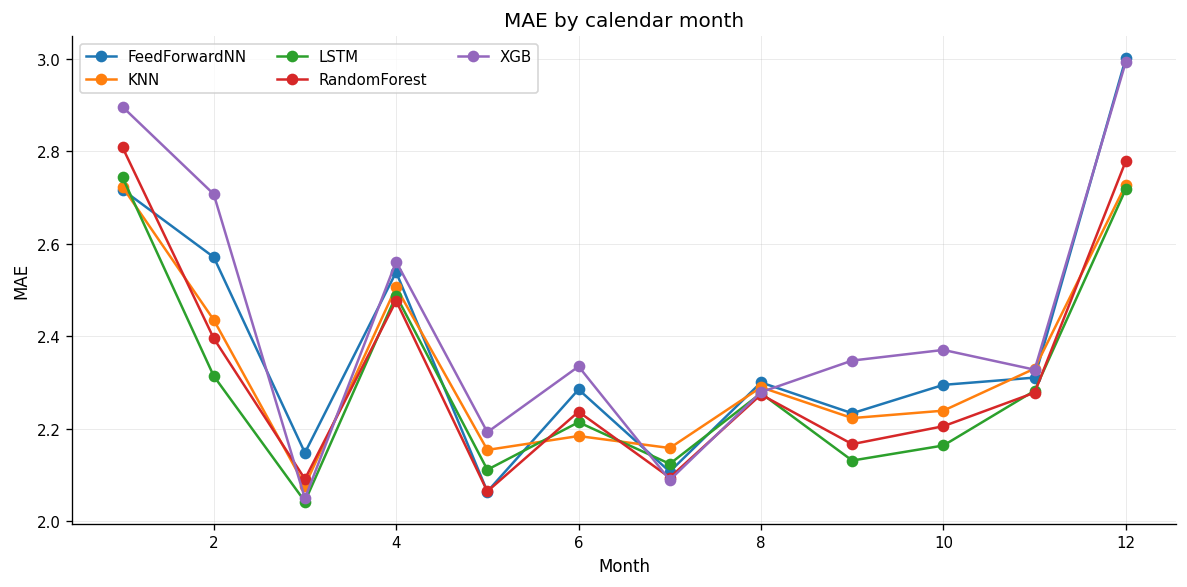

In [36]:
error_by_month = (
    forecasts.groupby(["model", "month"])
    .agg(mae=("abs_error", "mean"), bias=("residual", "mean"), n=("abs_error", "size"))
    .reset_index()
)
error_by_month.to_csv(OUT / "error_by_month.csv", index=False)

plt.figure(figsize=(10, 5))
for model_name, g in error_by_month.groupby("model"):
    if model_name in MODELS:
        plt.plot(g["month"], g["mae"], marker="o", label=model_name)
plt.title("MAE by calendar month")
plt.xlabel("Month")
plt.ylabel("MAE")
plt.legend(ncol=3)
plt.tight_layout()
plt.savefig(OUT / "error_by_month.png", dpi=180)
plt.show()

## PDP-Style Response Curves

Run this for selected tabular models and selected features. For ALE, use a dedicated ALE package if installed; PDP is included here because it is available in scikit-learn.

In [37]:
PDP_MODEL = "XGB"
PDP_FEATURES = ["dayofyear", "yday", "last_year", "diff_yday"]

try:
    payload, path = load_payload(PDP_MODEL, EXPLAIN_REGION, CALIB_YEAR)
    feature_cols = extract_feature_cols(payload)
    X, y = build_tabular_data(EXPLAIN_REGION, CALIB_YEAR, feature_cols)

    class WrappedModel:
        def predict(self, X_in):
            X_df = pd.DataFrame(X_in, columns=feature_cols)
            return predict_payload(payload, X_df)

    features = [f for f in PDP_FEATURES if f in feature_cols]
    PartialDependenceDisplay.from_estimator(WrappedModel(), X, features=features, kind="average")
    plt.tight_layout()
    plt.savefig(OUT / f"pdp_{PDP_MODEL.lower()}_region_{EXPLAIN_REGION}_{EXPLAIN_YEAR}.png", dpi=180)
    plt.show()
except Exception as e:
    print(f"PDP skipped: {type(e).__name__}: {e}")

PDP skipped: InvalidParameterError: The 'estimator' parameter of partial_dependence must be an object implementing 'fit' and 'predict', an object implementing 'fit' and 'predict_proba' or an object implementing 'fit' and 'decision_function'. Got <__main__.WrappedModel object at 0x33fe195b0> instead.


# Comparative Narrative Template

Use the saved tables to write the thesis discussion. Keep the language model-specific and connect explanation evidence to forecast error evidence.

In [38]:
narrative = pd.DataFrame([
    {
        "model_category": "Tree ensembles",
        "models": "XGB, RandomForest",
        "global_method": "TreeSHAP mean absolute attribution",
        "local_method": "local TreeSHAP",
        "interpretation_focus": "nonlinear lag/seasonality interactions and feature ranking stability",
    },
    {
        "model_category": "Kernel/distance models",
        "models": "SVR, KNN",
        "global_method": "permutation importance",
        "local_method": "LIME or local linear surrogate",
        "interpretation_focus": "sensitivity to feature perturbation and local neighborhood behavior",
    },
    {
        "model_category": "Neural models",
        "models": "FeedForwardNN, LSTM",
        "global_method": "permutation/ablation or Integrated Gradients where differentiable",
        "local_method": "local surrogate or temporal attribution",
        "interpretation_focus": "recursive dynamics, lookback dependence, and covariate contribution",
    },
])
narrative.to_csv(OUT / "comparative_narrative_template.csv", index=False)
narrative

,model_category,models,global_method,local_method,interpretation_focus
0,Tree ensembles,"XGB, RandomForest",TreeSHAP mean absolute attribution,local TreeSHAP,nonlinear lag/seasonality interactions and fea...
1,Kernel/distance models,"SVR, KNN",permutation importance,LIME or local linear surrogate,sensitivity to feature perturbation and local ...
2,Neural models,"FeedForwardNN, LSTM",permutation/ablation or Integrated Gradients w...,local surrogate or temporal attribution,"recursive dynamics, lookback dependence, and c..."


# Comparative Interpretation Tables

This section converts the raw attribution and diagnostic files into thesis-ready evidence tables. It is designed to answer four questions:

1. What each model learns
2. Why it performs well or poorly
3. Which features drive its predictions
4. How model structure interacts with the temperature data

In [39]:
def read_optional_csv(name: str) -> pd.DataFrame:
    path = OUT / name
    if path.exists():
        return pd.read_csv(path)
    print(f"Missing: {path}")
    return pd.DataFrame()




def show_df(df: pd.DataFrame, rows: int | None = None):
    obj = df if rows is None else df.head(rows)
    try:
        display(obj)
    except NameError:
        print(obj.to_string(index=False))


def display_model_name(model: str) -> str:
    return {"SVM": "SVR"}.get(str(model), str(model))


def feature_family(feature: str) -> str:
    f = str(feature)
    if f.startswith("history_") or f.startswith("target_history_"):
        return "calibration target history"
    if f in {"forecast_step"}:
        return "forecast horizon position"
    if f in {"dayofyear", "pdtn_doy", "month", "dts_doyavge", "dts_doyvar"}:
        return "seasonality/calendar"
    if f == "de_trend_seas":
        return "current deseasonalized state"
    if f in {"yday", "IIdays_ago", "IIIdays_ago", "IVdays_ago", "Vdays_ago", "VIdays_ago", "VIIdays_ago"}:
        return "short-run lag memory"
    if f.startswith("last_7_"):
        return "recent volatility"
    if f.startswith("last_") or f.startswith("h1_last") or f.startswith("h1_ly"):
        return "annual analogue memory"
    if f.startswith("diff_"):
        return "change/difference features"
    return "other"


def normalize_importance(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    out = df.copy()
    out["model"] = out["model"].map(display_model_name)
    mapped_family = out["feature"].map(feature_family)
    if "feature_family" in out.columns:
        out["feature_family"] = out["feature_family"].where(out["feature_family"].notna(), mapped_family)
    else:
        out["feature_family"] = mapped_family
    out["importance"] = pd.to_numeric(out["importance"], errors="coerce")
    totals = out.groupby("model")["importance"].transform(lambda s: s.abs().sum())
    out["importance_share"] = np.where(totals > 0, out["importance"].abs() / totals, np.nan)
    out["importance_rank"] = out.groupby("model")["importance"].rank(method="first", ascending=False)
    return out.sort_values(["model", "importance_rank"])


tree_imp = read_optional_csv("tree_global_importance.csv")
svm_knn_imp = read_optional_csv("svm_knn_permutation_importance.csv")
ffnn_imp = read_optional_csv("ffnn_global_importance.csv")
lstm_imp = read_optional_csv("lstm_model_agnostic_importance.csv")

if not tree_imp.empty:
    tree_imp["method"] = "TreeSHAP"
if not svm_knn_imp.empty:
    svm_knn_imp["method"] = "permutation"
if not ffnn_imp.empty:
    ffnn_imp["method"] = "permutation"
if not lstm_imp.empty and "method" not in lstm_imp.columns:
    lstm_imp["method"] = "model_agnostic_ablation"

importance_parts = []
for df in [tree_imp, svm_knn_imp, ffnn_imp, lstm_imp]:
    if not df.empty:
        keep = [c for c in ["model", "method", "feature", "importance", "std", "source"] if c in df.columns]
        importance_parts.append(df[keep])

all_importance = normalize_importance(pd.concat(importance_parts, ignore_index=True)) if importance_parts else pd.DataFrame()
all_importance.to_csv(OUT / "all_global_feature_importance_ranked.csv", index=False)

top_features = all_importance[all_importance["importance_rank"].le(10)].copy()
top_features.to_csv(OUT / "top_10_features_by_model.csv", index=False)

family_importance = (
    all_importance.groupby(["model", "feature_family"], as_index=False)
    .agg(
        total_importance=("importance", lambda s: float(np.nansum(np.abs(s)))),
        importance_share=("importance_share", "sum"),
        top_feature=("feature", "first"),
    )
    .sort_values(["model", "importance_share"], ascending=[True, False])
)
family_importance.to_csv(OUT / "feature_family_importance_by_model.csv", index=False)

show_df(top_features.groupby("model").head(5))
show_df(family_importance.groupby("model").head(3))

,model,method,feature,importance,source,std,feature_family,importance_share,importance_rank
200,FeedForwardNN,permutation,de_trend_seas,0.544396,/Users/marielouiselysholt/Desktop/Master/Maste...,0.077099,current deseasonalized state,0.106972,1.0
201,FeedForwardNN,permutation,diff_5year,0.487059,/Users/marielouiselysholt/Desktop/Master/Maste...,0.041730,change/difference features,0.095706,2.0
202,FeedForwardNN,permutation,diff_yday,0.473015,/Users/marielouiselysholt/Desktop/Master/Maste...,0.057735,change/difference features,0.092946,3.0
203,FeedForwardNN,permutation,IIdays_ago,0.411246,/Users/marielouiselysholt/Desktop/Master/Maste...,0.016201,short-run lag memory,0.080809,4.0
204,FeedForwardNN,permutation,last_5year,0.348726,/Users/marielouiselysholt/Desktop/Master/Maste...,0.034100,annual analogue memory,0.068524,5.0
100,KNN,permutation,de_trend_seas,3.479080,/Users/marielouiselysholt/Desktop/Master/Maste...,0.083645,current deseasonalized state,0.022224,1.0
101,KNN,permutation,diff_4year,3.314771,/Users/marielouiselysholt/Desktop/Master/Maste...,0.038656,change/difference features,0.021174,2.0
102,KNN,permutation,IIdays_ago,3.304438,/Users/marielouiselysholt/Desktop/Master/Maste...,0.059092,short-run lag memory,0.021108,3.0
103,KNN,permutation,diff_3year,3.270228,/Users/marielouiselysholt/Desktop/Master/Maste...,0.037064,change/difference features,0.020890,4.0
104,KNN,permutation,IIIdays_ago,3.264415,/Users/marielouiselysholt/Desktop/Master/Maste...,0.103476,short-run lag memory,0.020852,5.0


,model,feature_family,total_importance,importance_share,top_feature
1,FeedForwardNN,change/difference features,1.844063,0.362353,diff_5year
0,FeedForwardNN,annual analogue memory,1.158853,0.227711,last_5year
5,FeedForwardNN,short-run lag memory,1.152690,0.226500,IIdays_ago
6,KNN,annual analogue memory,70.497085,0.450321,h1_last_5years
7,KNN,change/difference features,38.019124,0.242859,diff_4year
11,KNN,short-run lag memory,22.729177,0.145189,IIdays_ago
12,LSTM,calibration target history,0.679557,0.883787,history_mean_365d
14,LSTM,seasonality/calendar,0.050448,0.065610,dayofyear
13,LSTM,forecast horizon position,0.038910,0.050604,forecast_step
16,RandomForest,change/difference features,1.485449,0.933448,diff_4year


## Performance And Error Profile

This table links the explanation evidence to model behavior. Use it to discuss whether a model is accurate on average, biased upward/downward, unstable across regions/years, or weak in specific seasons.

In [40]:
forecasts_path = ROOT / "bk_forecasts.csv"
if forecasts_path.exists():
    forecast_coverage_source = pd.read_csv(forecasts_path, usecols=["model", "actual", "forecast"])
    forecast_coverage_source["model"] = forecast_coverage_source["model"].map(display_model_name)
    coverage = (
        forecast_coverage_source.groupby("model")
        .agg(
            rows=("forecast", "size"),
            forecast_count=("forecast", "count"),
            actual_count=("actual", "count"),
            forecast_missing=("forecast", lambda s: int(s.isna().sum())),
        )
        .reset_index()
    )
    coverage["forecast_missing_share"] = coverage["forecast_missing"] / coverage["rows"]
    coverage.to_csv(OUT / "forecast_coverage_by_model.csv", index=False)
else:
    coverage = read_optional_csv("forecast_coverage_by_model.csv")
    if not coverage.empty:
        coverage = coverage.copy()
        coverage["model"] = coverage["model"].map(display_model_name)

residuals = read_optional_csv("residual_summary_model_region_year.csv")
monthly = read_optional_csv("error_by_month.csv")

if not residuals.empty:
    residuals = residuals.copy()
    residuals["model"] = residuals["model"].map(display_model_name)
    valid_residuals = residuals.dropna(subset=["mae", "rmse"])
    performance_profile = (
        valid_residuals.groupby("model", as_index=False)
        .agg(
            mean_mae=("mae", "mean"),
            median_mae=("mae", "median"),
            mean_rmse=("rmse", "mean"),
            mean_bias=("bias", "mean"),
            abs_bias=("bias", lambda s: float(np.nanmean(np.abs(s)))),
            region_years=("mae", "count"),
            mae_std=("mae", "std"),
        )
    )
    performance_profile["mae_rank"] = performance_profile["mean_mae"].rank(method="min")
else:
    performance_profile = pd.DataFrame()

if not coverage.empty and not performance_profile.empty:
    performance_profile = performance_profile.merge(
        coverage[["model", "rows", "forecast_count", "forecast_missing_share"]],
        on="model",
        how="left",
    )

if not monthly.empty:
    monthly = monthly.copy()
    monthly["model"] = monthly["model"].map(display_model_name)
    valid_monthly = monthly.dropna(subset=["mae"])
    worst_month = valid_monthly.loc[valid_monthly.groupby("model")["mae"].idxmax(), ["model", "month", "mae"]]
    worst_month = worst_month.rename(columns={"month": "worst_month", "mae": "worst_month_mae"})
    best_month = valid_monthly.loc[valid_monthly.groupby("model")["mae"].idxmin(), ["model", "month", "mae"]]
    best_month = best_month.rename(columns={"month": "best_month", "mae": "best_month_mae"})
    seasonal_profile = worst_month.merge(best_month, on="model", how="outer")
else:
    seasonal_profile = pd.DataFrame()

if not performance_profile.empty and not seasonal_profile.empty:
    performance_profile = performance_profile.merge(seasonal_profile, on="model", how="left")

performance_profile = performance_profile.sort_values("mean_mae") if not performance_profile.empty else performance_profile
performance_profile.to_csv(OUT / "model_performance_profile.csv", index=False)
show_df(performance_profile)

,model,mean_mae,median_mae,mean_rmse,mean_bias,abs_bias,region_years,mae_std,mae_rank,rows,forecast_count,forecast_missing_share,worst_month,worst_month_mae,best_month,best_month_mae
4,SVR,2.253772,2.348941,2.810122,-0.429580,0.429580,80,0.299541,1.0,29200,29200,0.0,12,2.710190,3,2.003674
2,LSTM,2.301044,2.401829,2.854622,-0.686872,0.686872,80,0.306835,2.0,29200,29200,0.0,1,2.743985,3,2.042508
3,RandomForest,2.322392,2.400951,2.903731,-0.428576,0.727390,80,0.335088,3.0,29200,29200,0.0,1,2.809042,5,2.064387
1,KNN,2.336935,2.425987,2.919009,-0.547074,0.547074,80,0.328523,4.0,29200,29200,0.0,12,2.728535,3,2.077055
0,FeedForwardNN,2.379936,2.437257,2.981402,0.041728,0.483314,80,0.324750,5.0,29200,29200,0.0,12,3.001945,5,2.064037
5,XGB,2.427302,2.483467,3.004669,0.153745,0.470276,80,0.303953,6.0,29200,29200,0.0,12,2.994083,3,2.049062


## Error By Feature Bins

This checks whether errors are concentrated in specific data regimes: very cold/warm deseasonalized states, large day-to-day changes, or parts of the year. It helps explain *why* a model performs well or poorly.

In [41]:
key_bin_features = ["de_trend_seas", "diff_yday", "dayofyear"]
forecasts_path = ROOT / "bk_forecasts.csv"

if forecasts_path.exists():
    forecasts_for_bins = pd.read_csv(forecasts_path, parse_dates=["date"])
    forecasts_for_bins["model"] = forecasts_for_bins["model"].map(display_model_name)
    forecasts_for_bins = forecasts_for_bins.dropna(subset=["actual", "forecast"]).copy()
    forecasts_for_bins["abs_error"] = (forecasts_for_bins["actual"] - forecasts_for_bins["forecast"]).abs()
    forecasts_for_bins["bias"] = forecasts_for_bins["actual"] - forecasts_for_bins["forecast"]

    ext_region = load_extended_region(EXPLAIN_REGION).reset_index()
    feature_cols_for_bins = ["date"] + [f for f in key_bin_features if f in ext_region.columns]
    merged_bins = forecasts_for_bins.merge(ext_region[feature_cols_for_bins], on="date", how="left")
    merged_bins = merged_bins[merged_bins["region"].eq(EXPLAIN_REGION)].copy()

    bin_rows = []
    for feature in [f for f in key_bin_features if f in merged_bins.columns]:
        values = pd.to_numeric(merged_bins[feature], errors="coerce")
        if values.notna().sum() < 20:
            continue
        labels = ["low", "mid-low", "mid-high", "high"]
        try:
            merged_bins[f"{feature}_bin"] = pd.qcut(values, q=4, labels=labels, duplicates="drop")
        except ValueError:
            continue
        grouped = (
            merged_bins.dropna(subset=[f"{feature}_bin"])
            .groupby(["model", f"{feature}_bin"], observed=False)
            .agg(mae=("abs_error", "mean"), bias=("bias", "mean"), n=("abs_error", "size"))
            .reset_index()
            .rename(columns={f"{feature}_bin": "bin"})
        )
        grouped["feature"] = feature
        bin_rows.append(grouped[["model", "feature", "bin", "mae", "bias", "n"]])

    error_by_feature_bins = pd.concat(bin_rows, ignore_index=True) if bin_rows else pd.DataFrame()
else:
    error_by_feature_bins = pd.DataFrame()

error_by_feature_bins.to_csv(OUT / "error_by_feature_bins.csv", index=False)
show_df(error_by_feature_bins, 30)

,model,feature,bin,mae,bias,n
0,FeedForwardNN,de_trend_seas,low,4.448830,-4.442721,913
1,FeedForwardNN,de_trend_seas,mid-low,1.835722,-1.718801,912
2,FeedForwardNN,de_trend_seas,mid-high,1.041684,0.351725,913
3,FeedForwardNN,de_trend_seas,high,3.424659,3.391711,912
4,KNN,de_trend_seas,low,4.459405,-4.457837,913
5,KNN,de_trend_seas,mid-low,1.708496,-1.683164,912
6,KNN,de_trend_seas,mid-high,0.830495,0.339903,913
7,KNN,de_trend_seas,high,3.344154,3.342354,912
8,LSTM,de_trend_seas,low,4.706618,-4.705637,913
9,LSTM,de_trend_seas,mid-low,1.958186,-1.953102,912


## Automated Comparative Narrative Evidence

This table is a draft evidence scaffold. Use it as the basis for the written discussion, then refine the language in your thesis.

In [42]:
MODEL_STRUCTURE_NOTES = {
    "XGB": "Gradient-boosted trees learn nonlinear threshold rules and interactions. They often perform well when a few state/lag variables split the temperature process into regimes.",
    "RandomForest": "Random forests average many decorrelated trees. They tend to be robust but can smooth extremes and rely strongly on repeated lag/year-analogue patterns.",
    "SVR": "SVR learns a smooth kernel-based response. It can perform well when the signal is continuous and stable, but it may under-react to abrupt regime changes.",
    "KNN": "KNN forecasts by similarity to nearby historical feature vectors. It performs well when close analogues exist, but struggles in sparse or unusual weather states.",
    "FeedForwardNN": "The feed-forward network learns nonlinear combinations of tabular lags. It can capture interactions, but recursive forecasting can amplify small one-step errors.",
    "LSTM": "The LSTM is structured for temporal dependence. It can learn sequence patterns, but it needs enough stable history and careful covariate attribution to explain cleanly.",
}


def join_top_features(model: str, n=5) -> str:
    if top_features.empty:
        return "not available"
    g = top_features[top_features["model"].eq(model)].sort_values("importance_rank").head(n)
    if g.empty:
        return "not available"
    return ", ".join(g["feature"].astype(str).tolist())


def dominant_family(model: str) -> str:
    if family_importance.empty:
        return "not available"
    g = family_importance[family_importance["model"].eq(model)].sort_values("importance_share", ascending=False)
    if g.empty:
        return "not available"
    row = g.iloc[0]
    return f"{row['feature_family']} ({row['importance_share']:.1%} of normalized importance)"


def performance_sentence(model: str) -> str:
    if performance_profile.empty or model not in set(performance_profile["model"]):
        return "No valid forecast diagnostics available."
    row = performance_profile[performance_profile["model"].eq(model)].iloc[0]
    bias_direction = "under-forecasting" if row["mean_bias"] > 0 else "over-forecasting"
    return (
        f"Mean MAE {row['mean_mae']:.3f}, RMSE {row['mean_rmse']:.3f}, "
        f"average bias {row['mean_bias']:.3f} ({bias_direction} on average when signed bias is material)."
    )


def learns_sentence(model: str) -> str:
    fam = dominant_family(model)
    feats = join_top_features(model)
    if feats == "not available":
        return "Attribution evidence is not yet available for this model."
    return f"Primarily learns from {fam}; strongest individual drivers are {feats}."

models_for_narrative = ["XGB", "RandomForest", "SVR", "KNN", "FeedForwardNN", "LSTM"]
rows = []
for model in models_for_narrative:
    rows.append({
        "model": model,
        "what_it_learns": learns_sentence(model),
        "why_it_performs_well_or_poorly": performance_sentence(model),
        "features_driving_predictions": join_top_features(model),
        "dominant_feature_family": dominant_family(model),
        "structure_data_interaction": MODEL_STRUCTURE_NOTES.get(model, ""),
    })

comparative_interpretation = pd.DataFrame(rows)
comparative_interpretation.to_csv(OUT / "comparative_model_interpretation.csv", index=False)
show_df(comparative_interpretation)

,model,what_it_learns,why_it_performs_well_or_poorly,features_driving_predictions,dominant_feature_family,structure_data_interaction
0,XGB,Primarily learns from current deseasonalized s...,"Mean MAE 2.427, RMSE 3.005, average bias 0.154...","de_trend_seas, last_7_1day_deltas_max, h1_last...",current deseasonalized state (81.7% of normali...,Gradient-boosted trees learn nonlinear thresho...
1,RandomForest,Primarily learns from change/difference featur...,"Mean MAE 2.322, RMSE 2.904, average bias -0.42...","diff_4year, diff_3year, diff_yday, diff_1year,...",change/difference features (93.3% of normalize...,Random forests average many decorrelated trees...
2,SVR,Primarily learns from change/difference featur...,"Mean MAE 2.254, RMSE 2.810, average bias -0.43...","diff_yday, de_trend_seas, IIdays_ago, IIIdays_...",change/difference features (38.5% of normalize...,SVR learns a smooth kernel-based response. It ...
3,KNN,Primarily learns from annual analogue memory (...,"Mean MAE 2.337, RMSE 2.919, average bias -0.54...","de_trend_seas, diff_4year, IIdays_ago, diff_3y...",annual analogue memory (45.0% of normalized im...,KNN forecasts by similarity to nearby historic...
4,FeedForwardNN,Primarily learns from change/difference featur...,"Mean MAE 2.380, RMSE 2.981, average bias 0.042...","de_trend_seas, diff_5year, diff_yday, IIdays_a...",change/difference features (36.2% of normalize...,The feed-forward network learns nonlinear comb...
5,LSTM,Primarily learns from calibration target histo...,"Mean MAE 2.301, RMSE 2.855, average bias -0.68...","history_mean_365d, history_std_365d, forecast_...",calibration target history (88.4% of normalize...,The LSTM is structured for temporal dependence...


# Publication-Ready Visualizations

These figures summarize the explainability and diagnostic outputs in a consistent publication style. They are saved to `analysis_outputs/explainability/figures` as high-resolution PNG and PDF files.

In [43]:
FIG_DIR = OUT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PALETTE = {
    "XGB": "#4C78A8",
    "RandomForest": "#59A14F",
    "SVR": "#E15759",
    "SVM": "#E15759",
    "KNN": "#F28E2B",
    "FeedForwardNN": "#B07AA1",
    "LSTM": "#76B7B2",
    "HBA": "#8C8C8C",
    "Alaton": "#BAB0AC",
    "Benth": "#9C755F",
}

FAMILY_PALETTE = {
    "current deseasonalized state": "#4C78A8",
    "change/difference features": "#E15759",
    "short-run lag memory": "#F28E2B",
    "annual analogue memory": "#59A14F",
    "recent volatility": "#B07AA1",
    "seasonality/calendar": "#76B7B2",
    "forecast-time seasonal covariates": "#76B7B2",
    "calibration target history": "#EDC948",
    "forecast horizon position": "#FF9DA7",
    "other": "#8C8C8C",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
})


def clean_label(value: str) -> str:
    labels = {
        "de_trend_seas": "Current deseasonalized state",
        "diff_yday": "Change from yesterday",
        "diff_1year": "Change vs 1 year ago",
        "diff_2year": "Change vs 2 years ago",
        "diff_3year": "Change vs 3 years ago",
        "diff_4year": "Change vs 4 years ago",
        "diff_5year": "Change vs 5 years ago",
        "IIdays_ago": "2-day lag",
        "IIIdays_ago": "3-day lag",
        "yday": "Yesterday",
        "dayofyear": "Day of year",
        "pdtn_doy": "Prediction day of year",
        "last_7_1day_deltas_max": "Max recent daily change",
        "last_7_1day_deltas_mean": "Mean recent daily change",
        "h1_last_5years": "Annual analogue, 5 years",
        "last_5year": "Same day, 5 years ago",
    }
    return labels.get(str(value), str(value).replace("_", " "))


def save_figure(fig, name: str):
    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"
    fig.savefig(png, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    print(f"saved -> {png}")
    print(f"saved -> {pdf}")


def annotate_bars(ax, fmt="{:.2f}", pad=0.01):
    xlim = ax.get_xlim()
    span = xlim[1] - xlim[0]
    for patch in ax.patches:
        width = patch.get_width()
        if not np.isfinite(width):
            continue
        ax.text(
            width + span * pad,
            patch.get_y() + patch.get_height() / 2,
            fmt.format(width),
            va="center",
            ha="left",
            fontsize=8,
        )
    ax.set_xlim(xlim[0], xlim[1] + span * 0.12)


print(f"Figures -> {FIG_DIR}")

Figures -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures


## Figure 1: Overall Model Performance

Ranks models by average MAE and shows RMSE/bias context. This answers which models perform best overall and whether errors are systematically directional.

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_01_model_mean_mae.png
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_01_model_mean_mae.pdf


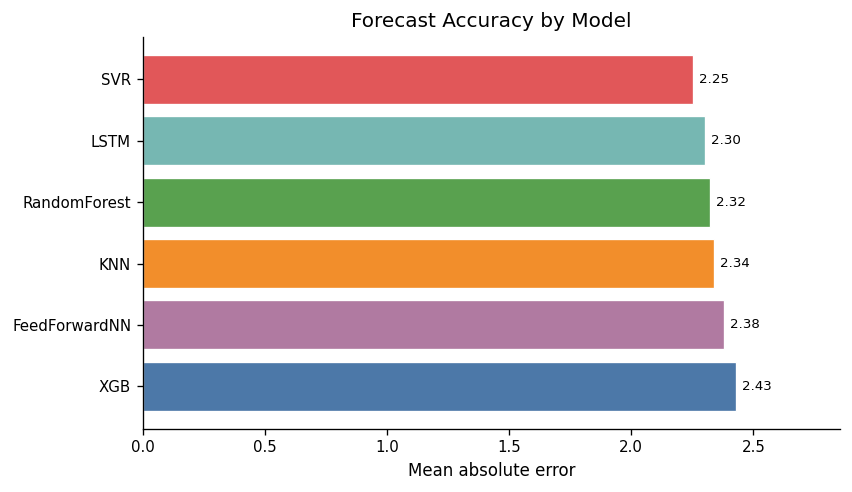

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_02_model_mean_bias.png
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_02_model_mean_bias.pdf


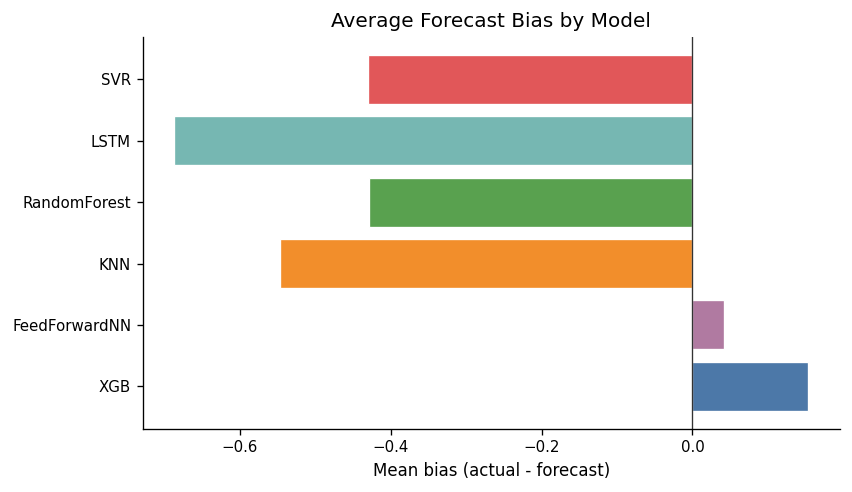

In [44]:
performance_profile = read_optional_csv("model_performance_profile.csv")
if not performance_profile.empty:
    perf = performance_profile.dropna(subset=["mean_mae"]).copy()
    perf = perf.sort_values("mean_mae", ascending=True)

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    colors = [MODEL_PALETTE.get(m, "#8C8C8C") for m in perf["model"]]
    ax.barh(perf["model"], perf["mean_mae"], color=colors, edgecolor="white", linewidth=0.8)
    ax.invert_yaxis()
    ax.set_xlabel("Mean absolute error")
    ax.set_ylabel("")
    ax.set_title("Forecast Accuracy by Model")
    annotate_bars(ax, fmt="{:.2f}")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)
    fig.tight_layout()
    save_figure(fig, "fig_01_model_mean_mae")
    plt.show()

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.axvline(0, color="#333333", linewidth=0.8)
    bias_colors = [MODEL_PALETTE.get(m, "#8C8C8C") for m in perf["model"]]
    ax.barh(perf["model"], perf["mean_bias"], color=bias_colors, edgecolor="white", linewidth=0.8)
    ax.invert_yaxis()
    ax.set_xlabel("Mean bias (actual - forecast)")
    ax.set_ylabel("")
    ax.set_title("Average Forecast Bias by Model")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)
    fig.tight_layout()
    save_figure(fig, "fig_02_model_mean_bias")
    plt.show()
else:
    print("model_performance_profile.csv is missing or empty")

## Figure 2: Feature Drivers by Model

Shows the top global drivers for each explainable tabular model. Importance values are normalized within model so the plot compares reliance patterns rather than raw SHAP/permutation scales.

## Figure 3: Feature-Family Reliance

Aggregates individual features into interpretable families: current state, short lags, annual analogues, differences, recent volatility, and seasonality.

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_04_feature_family_reliance.png
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_04_feature_family_reliance.pdf


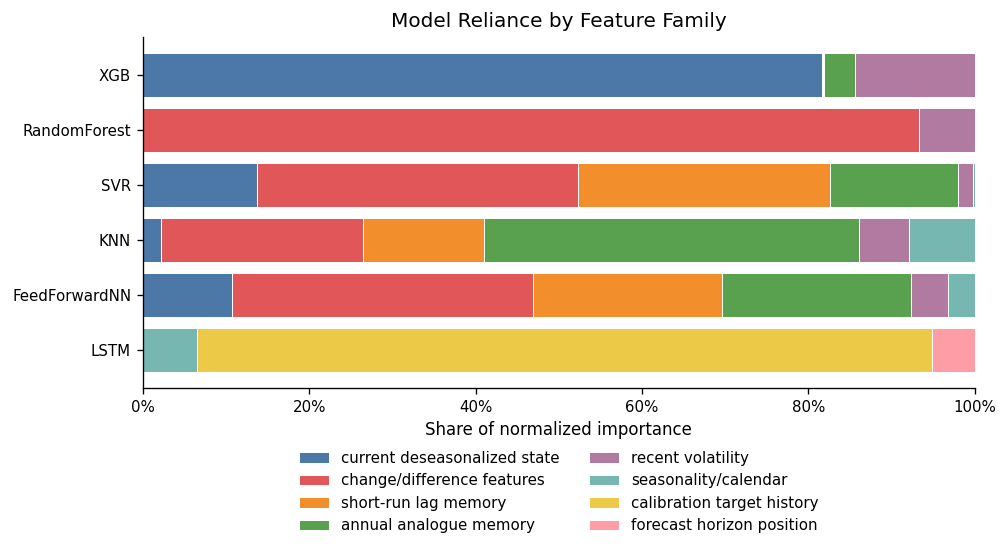

In [45]:
family_importance = read_optional_csv("feature_family_importance_by_model.csv")
if not family_importance.empty:
    fam = family_importance.copy()
    fam["model"] = fam["model"].map(display_model_name)
    fam = fam[fam["model"].isin(["XGB", "RandomForest", "SVR", "KNN", "FeedForwardNN", "LSTM"])]
    pivot = fam.pivot_table(index="model", columns="feature_family", values="importance_share", aggfunc="sum", fill_value=0)
    order = [m for m in ["XGB", "RandomForest", "SVR", "KNN", "FeedForwardNN", "LSTM"] if m in pivot.index]
    pivot = pivot.loc[order]
    families = [f for f in FAMILY_PALETTE if f in pivot.columns]
    pivot = pivot[families]

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    left = np.zeros(len(pivot))
    y = np.arange(len(pivot))
    for family in families:
        vals = pivot[family].to_numpy()
        ax.barh(y, vals, left=left, color=FAMILY_PALETTE[family], edgecolor="white", linewidth=0.6, label=family)
        left += vals
    ax.set_yticks(y)
    ax.set_yticklabels(pivot.index)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_xlabel("Share of normalized importance")
    ax.set_title("Model Reliance by Feature Family")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False)
    fig.tight_layout()
    save_figure(fig, "fig_04_feature_family_reliance")
    plt.show()
else:
    print("feature_family_importance_by_model.csv is missing or empty")

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_03_top_feature_drivers_by_model.png
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_03_top_feature_drivers_by_model.pdf


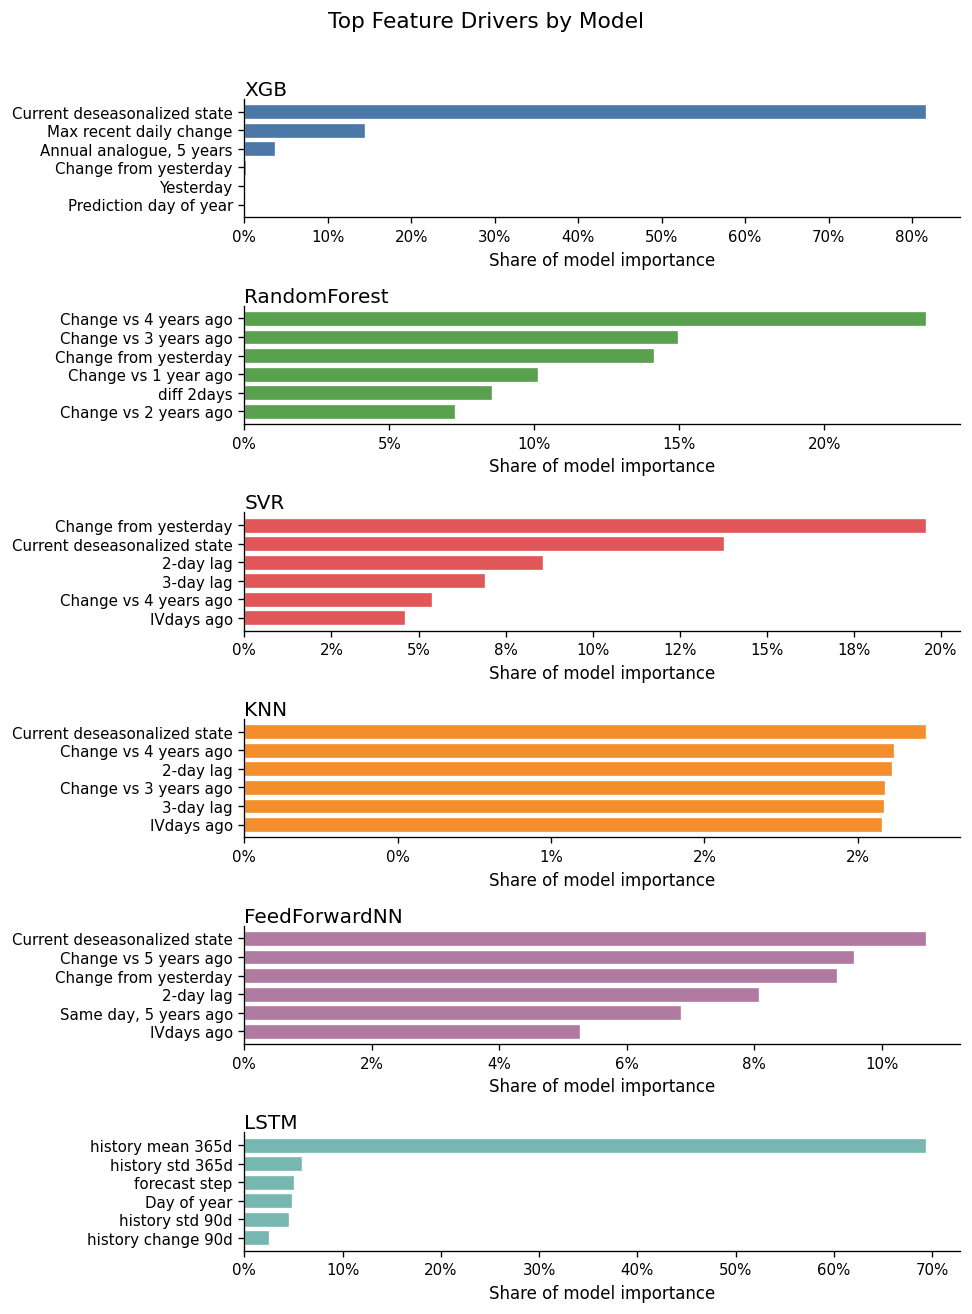

In [ ]:
top_features = read_optional_csv("top_10_features_by_model.csv")
if not top_features.empty:
    top_plot = top_features.copy()
    top_plot["model"] = top_plot["model"].map(display_model_name)
    top_plot["feature_label"] = top_plot["feature"].map(clean_label)
    top_plot = top_plot[top_plot["importance_rank"].le(6)]

    models = [m for m in ["XGB", "RandomForest", "SVR", "KNN", "FeedForwardNN", "LSTM"] if m in set(top_plot["model"])]
    fig, axes = plt.subplots(len(models), 1, figsize=(8.2, max(2.2, 1.8 * len(models))), sharex=False)
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        g = top_plot[top_plot["model"].eq(model)].sort_values("importance_share", ascending=True)
        ax.barh(g["feature_label"], g["importance_share"], color=MODEL_PALETTE.get(model, "#8C8C8C"), edgecolor="white", linewidth=0.8)
        ax.set_title(model, loc="left", pad=2)
        ax.set_xlabel("Share of model importance")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
        ax.grid(axis="x")
        ax.grid(axis="y", visible=False)

    fig.suptitle("Top Feature Drivers by Model", y=1.01, fontsize=13)
    fig.tight_layout()
    save_figure(fig, "fig_03_top_feature_drivers_by_model")
    plt.show()
else:
    print("top_10_features_by_model.csv is missing or empty")

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_03_top_feature_drivers_by_model.png
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_03_top_feature_drivers_by_model.pdf


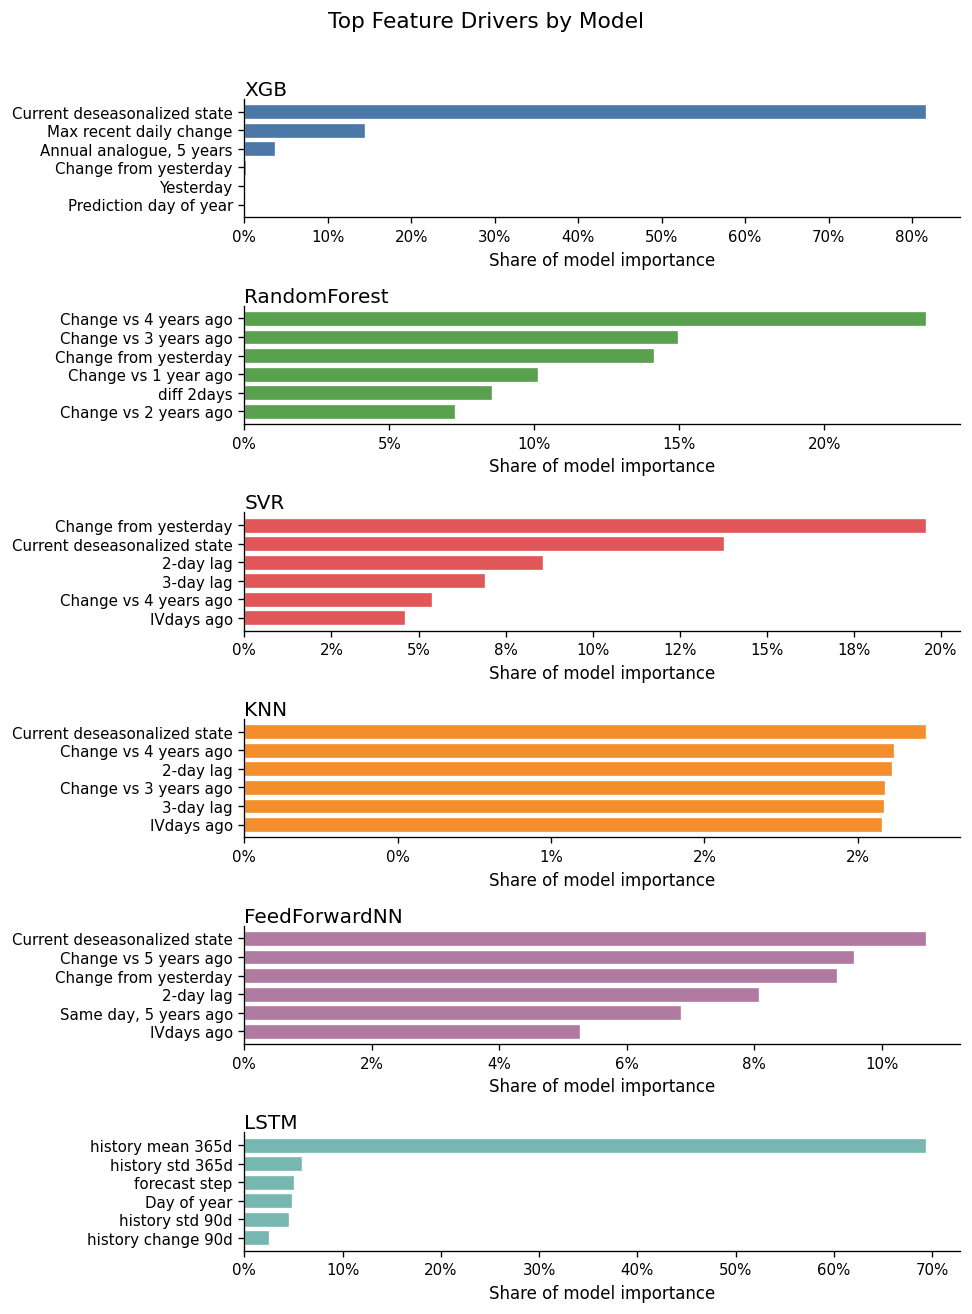

In [ ]:
top_features = read_optional_csv("top_10_features_by_model.csv")
if not top_features.empty:
    top_plot = top_features.copy()
    top_plot["model"] = top_plot["model"].map(display_model_name)
    top_plot["feature_label"] = top_plot["feature"].map(clean_label)
    top_plot = top_plot[top_plot["importance_rank"].le(6)]

    models = [m for m in ["XGB", "RandomForest", "SVR", "KNN", "FeedForwardNN", "LSTM"] if m in set(top_plot["model"])]
    fig, axes = plt.subplots(len(models), 1, figsize=(8.2, max(2.2, 1.8 * len(models))), sharex=False)
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        g = top_plot[top_plot["model"].eq(model)].sort_values("importance_share", ascending=True)
        ax.barh(g["feature_label"], g["importance_share"], color=MODEL_PALETTE.get(model, "#8C8C8C"), edgecolor="white", linewidth=0.8)
        ax.set_title(model, loc="left", pad=2)
        ax.set_xlabel("Share of model importance")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
        ax.grid(axis="x")
        ax.grid(axis="y", visible=False)

    fig.suptitle("Top Feature Drivers by Model", y=1.01, fontsize=13)
    fig.tight_layout()
    save_figure(fig, "fig_03_top_feature_drivers_by_model")
    plt.show()
else:
    print("top_10_features_by_model.csv is missing or empty")

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_03_top_feature_drivers_by_model.png
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_03_top_feature_drivers_by_model.pdf


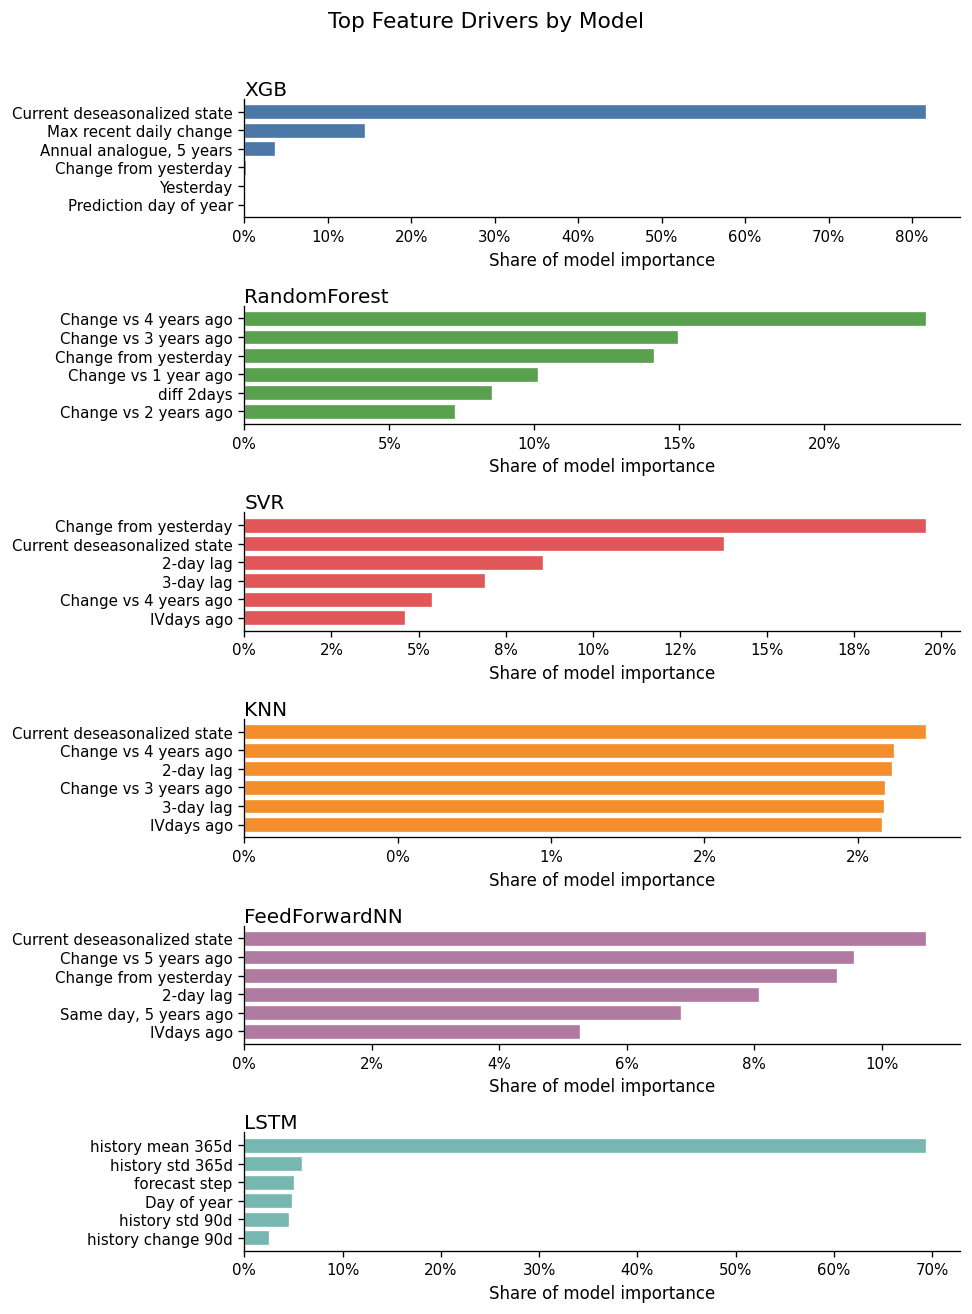

In [ ]:
top_features = read_optional_csv("top_10_features_by_model.csv")
if not top_features.empty:
    top_plot = top_features.copy()
    top_plot["model"] = top_plot["model"].map(display_model_name)
    top_plot["feature_label"] = top_plot["feature"].map(clean_label)
    top_plot = top_plot[top_plot["importance_rank"].le(6)]

    models = [m for m in ["XGB", "RandomForest", "SVR", "KNN", "FeedForwardNN", "LSTM"] if m in set(top_plot["model"])]
    fig, axes = plt.subplots(len(models), 1, figsize=(8.2, max(2.2, 1.8 * len(models))), sharex=False)
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        g = top_plot[top_plot["model"].eq(model)].sort_values("importance_share", ascending=True)
        ax.barh(g["feature_label"], g["importance_share"], color=MODEL_PALETTE.get(model, "#8C8C8C"), edgecolor="white", linewidth=0.8)
        ax.set_title(model, loc="left", pad=2)
        ax.set_xlabel("Share of model importance")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
        ax.grid(axis="x")
        ax.grid(axis="y", visible=False)

    fig.suptitle("Top Feature Drivers by Model", y=1.01, fontsize=13)
    fig.tight_layout()
    save_figure(fig, "fig_03_top_feature_drivers_by_model")
    plt.show()
else:
    print("top_10_features_by_model.csv is missing or empty")

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_03_top_feature_drivers_by_model.png
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_03_top_feature_drivers_by_model.pdf


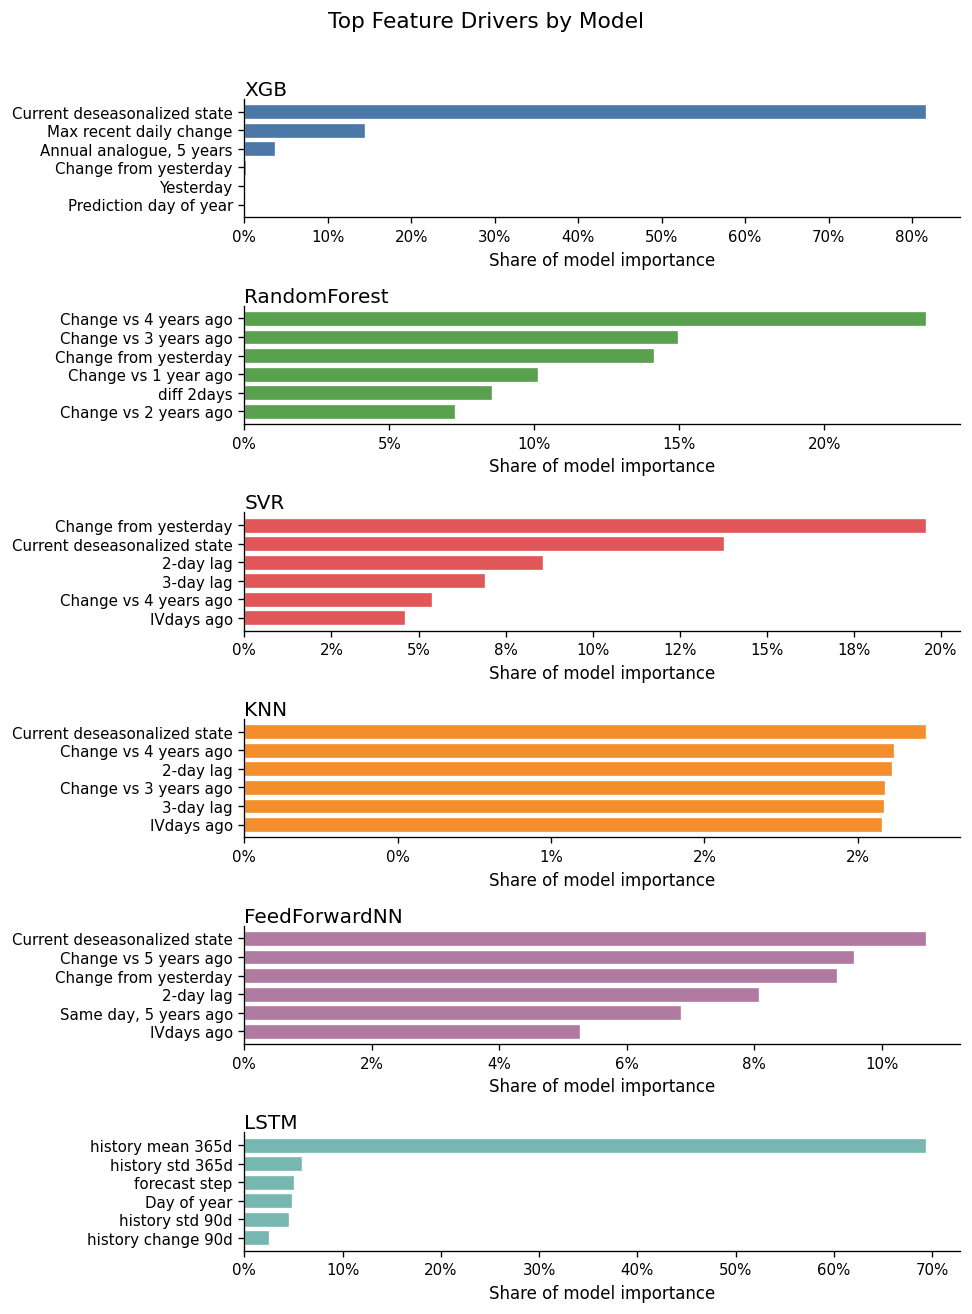

In [ ]:
top_features = read_optional_csv("top_10_features_by_model.csv")
if not top_features.empty:
    top_plot = top_features.copy()
    top_plot["model"] = top_plot["model"].map(display_model_name)
    top_plot["feature_label"] = top_plot["feature"].map(clean_label)
    top_plot = top_plot[top_plot["importance_rank"].le(6)]

    models = [m for m in ["XGB", "RandomForest", "SVR", "KNN", "FeedForwardNN", "LSTM"] if m in set(top_plot["model"])]
    fig, axes = plt.subplots(len(models), 1, figsize=(8.2, max(2.2, 1.8 * len(models))), sharex=False)
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        g = top_plot[top_plot["model"].eq(model)].sort_values("importance_share", ascending=True)
        ax.barh(g["feature_label"], g["importance_share"], color=MODEL_PALETTE.get(model, "#8C8C8C"), edgecolor="white", linewidth=0.8)
        ax.set_title(model, loc="left", pad=2)
        ax.set_xlabel("Share of model importance")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
        ax.grid(axis="x")
        ax.grid(axis="y", visible=False)

    fig.suptitle("Top Feature Drivers by Model", y=1.01, fontsize=13)
    fig.tight_layout()
    save_figure(fig, "fig_03_top_feature_drivers_by_model")
    plt.show()
else:
    print("top_10_features_by_model.csv is missing or empty")

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_03_top_feature_drivers_by_model.png
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_03_top_feature_drivers_by_model.pdf


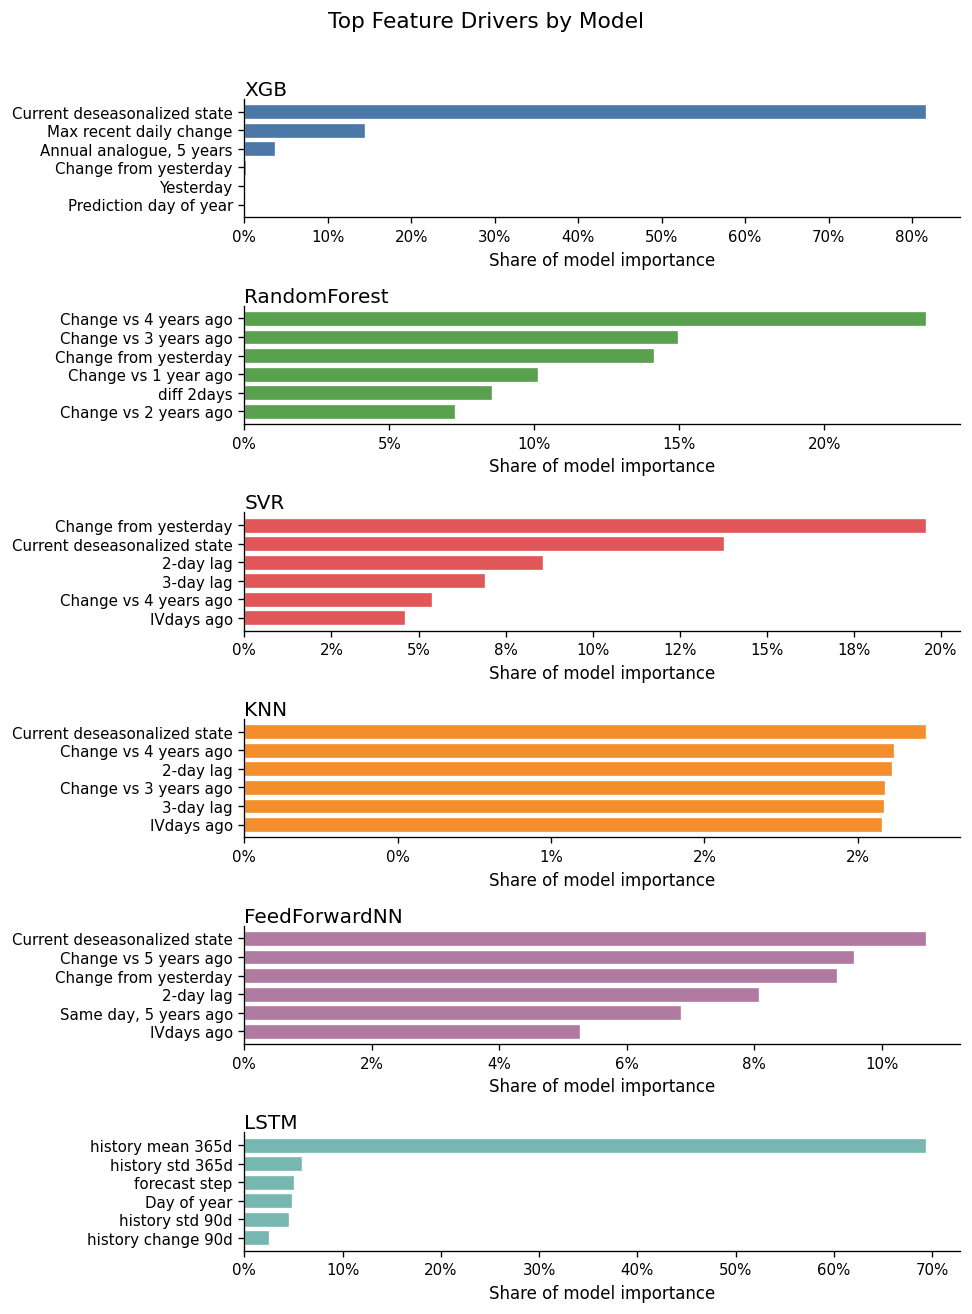

In [ ]:
top_features = read_optional_csv("top_10_features_by_model.csv")
if not top_features.empty:
    top_plot = top_features.copy()
    top_plot["model"] = top_plot["model"].map(display_model_name)
    top_plot["feature_label"] = top_plot["feature"].map(clean_label)
    top_plot = top_plot[top_plot["importance_rank"].le(6)]

    models = [m for m in ["XGB", "RandomForest", "SVR", "KNN", "FeedForwardNN", "LSTM"] if m in set(top_plot["model"])]
    fig, axes = plt.subplots(len(models), 1, figsize=(8.2, max(2.2, 1.8 * len(models))), sharex=False)
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        g = top_plot[top_plot["model"].eq(model)].sort_values("importance_share", ascending=True)
        ax.barh(g["feature_label"], g["importance_share"], color=MODEL_PALETTE.get(model, "#8C8C8C"), edgecolor="white", linewidth=0.8)
        ax.set_title(model, loc="left", pad=2)
        ax.set_xlabel("Share of model importance")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
        ax.grid(axis="x")
        ax.grid(axis="y", visible=False)

    fig.suptitle("Top Feature Drivers by Model", y=1.01, fontsize=13)
    fig.tight_layout()
    save_figure(fig, "fig_03_top_feature_drivers_by_model")
    plt.show()
else:
    print("top_10_features_by_model.csv is missing or empty")

## Figure 4: Seasonal Error Pattern

Shows whether models fail in specific months. This helps connect forecast performance to the seasonal temperature process.

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_05_monthly_mae_profile.png
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_05_monthly_mae_profile.pdf


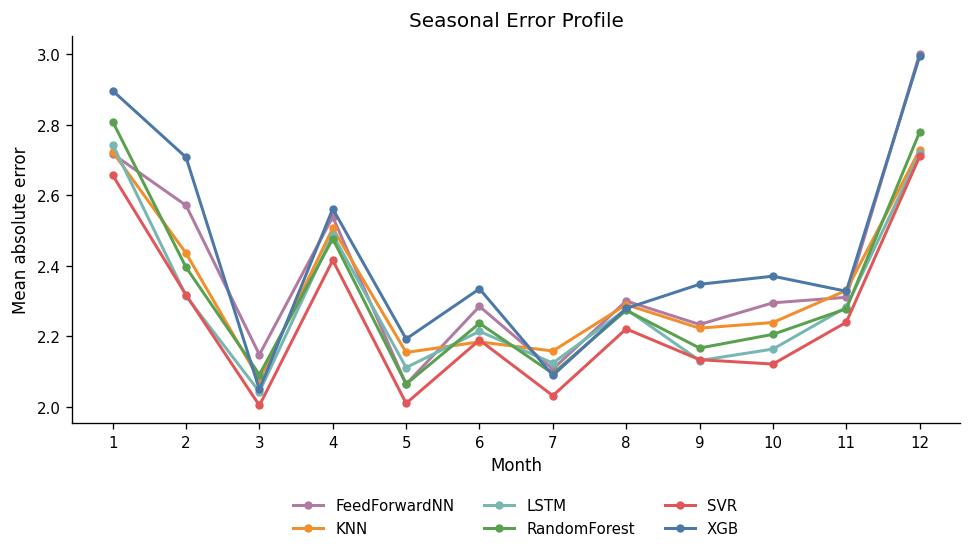

In [46]:
monthly = read_optional_csv("error_by_month.csv")
if not monthly.empty:
    monthly = monthly.copy()
    monthly["model"] = monthly["model"].map(display_model_name)
    monthly = monthly[monthly["model"].isin(["XGB", "RandomForest", "SVR", "KNN", "FeedForwardNN", "LSTM"])]
    monthly = monthly.dropna(subset=["mae"])

    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    for model, g in monthly.groupby("model"):
        g = g.sort_values("month")
        ax.plot(g["month"], g["mae"], marker="o", markersize=4, linewidth=1.8, label=model, color=MODEL_PALETTE.get(model, None))
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Month")
    ax.set_ylabel("Mean absolute error")
    ax.set_title("Seasonal Error Profile")
    ax.legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.16))
    ax.grid(axis="both")
    fig.tight_layout()
    save_figure(fig, "fig_05_monthly_mae_profile")
    plt.show()
else:
    print("error_by_month.csv is missing or empty")

## Figure 5: Error Regimes by Key Features

Shows where models struggle in the feature space. The bins are quartiles for the selected feature and region.

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_06_error_by_feature_regime.png
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_06_error_by_feature_regime.pdf


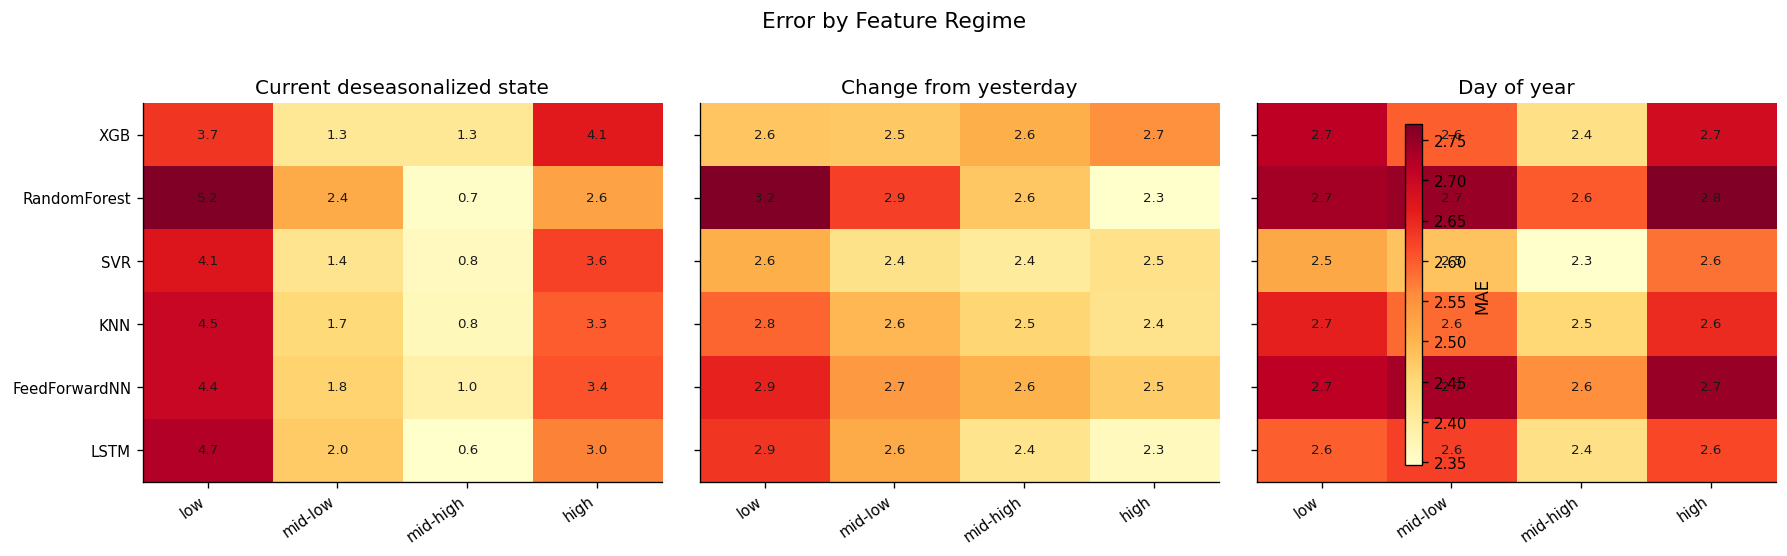

In [47]:
error_bins = read_optional_csv("error_by_feature_bins.csv")
if not error_bins.empty:
    bins = error_bins.copy()
    bins["model"] = bins["model"].map(display_model_name)
    bins = bins[bins["model"].isin(["XGB", "RandomForest", "SVR", "KNN", "FeedForwardNN", "LSTM"])]
    feature_order = [f for f in ["de_trend_seas", "diff_yday", "dayofyear"] if f in set(bins["feature"])]
    bin_order = ["low", "mid-low", "mid-high", "high"]

    fig, axes = plt.subplots(1, len(feature_order), figsize=(5.0 * len(feature_order), 4.5), sharey=True)
    if len(feature_order) == 1:
        axes = [axes]
    for ax, feature in zip(axes, feature_order):
        g = bins[bins["feature"].eq(feature)].copy()
        pivot = g.pivot_table(index="model", columns="bin", values="mae", aggfunc="mean")
        model_order = [m for m in ["XGB", "RandomForest", "SVR", "KNN", "FeedForwardNN", "LSTM"] if m in pivot.index]
        pivot = pivot.reindex(model_order)[[b for b in bin_order if b in pivot.columns]]
        im = ax.imshow(pivot.to_numpy(), aspect="auto", cmap="YlOrRd")
        ax.set_title(clean_label(feature))
        ax.set_xticks(np.arange(pivot.shape[1]))
        ax.set_xticklabels(pivot.columns, rotation=35, ha="right")
        ax.set_yticks(np.arange(pivot.shape[0]))
        ax.set_yticklabels(pivot.index)
        ax.grid(False)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.iloc[i, j]
                if np.isfinite(val):
                    ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8, color="#1a1a1a")
    cbar = fig.colorbar(im, ax=axes, shrink=0.82, pad=0.02)
    cbar.set_label("MAE")
    fig.suptitle("Error by Feature Regime", y=1.02, fontsize=13)
    fig.tight_layout()
    save_figure(fig, "fig_06_error_by_feature_regime")
    plt.show()
else:
    print("error_by_feature_bins.csv is missing or empty")

## Figure 6: Local Tree Explanation

Compares local feature contributions for one forecast from XGB and RandomForest.

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_07_local_tree_explanations.png
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_07_local_tree_explanations.pdf


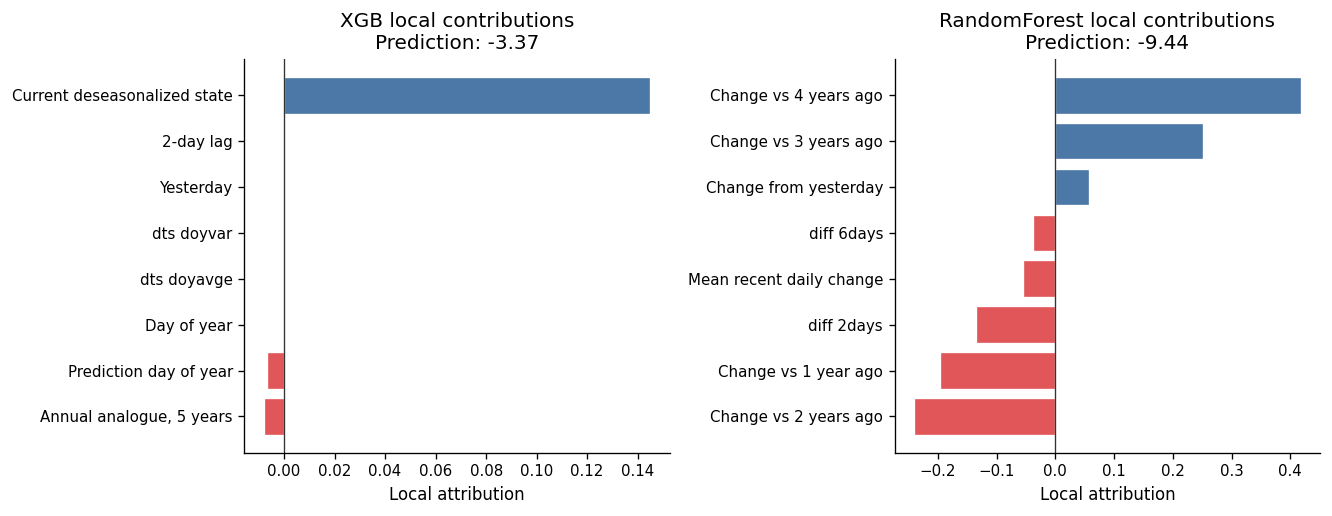

In [48]:
local_tree = read_optional_csv("tree_local_explanations.csv")
if not local_tree.empty:
    loc = local_tree.copy()
    loc["feature_label"] = loc["feature"].map(clean_label)
    loc["abs_attr"] = loc["local_attribution"].abs()
    models = [m for m in ["XGB", "RandomForest"] if m in set(loc["model"])]
    fig, axes = plt.subplots(1, len(models), figsize=(5.6 * len(models), 4.4), sharex=False)
    if len(models) == 1:
        axes = [axes]
    for ax, model in zip(axes, models):
        g = loc[loc["model"].eq(model)].nlargest(8, "abs_attr").sort_values("local_attribution")
        colors = np.where(g["local_attribution"] >= 0, "#4C78A8", "#E15759")
        ax.axvline(0, color="#333333", linewidth=0.8)
        ax.barh(g["feature_label"], g["local_attribution"], color=colors, edgecolor="white", linewidth=0.8)
        pred = g["prediction"].iloc[0] if "prediction" in g else np.nan
        ax.set_title(f"{model} local contributions\nPrediction: {pred:.2f}")
        ax.set_xlabel("Local attribution")
        ax.grid(axis="x")
        ax.grid(axis="y", visible=False)
    fig.tight_layout()
    save_figure(fig, "fig_07_local_tree_explanations")
    plt.show()
else:
    print("tree_local_explanations.csv is missing or empty")

## Figure 7: Performance Versus Explanation Pattern

A compact summary linking accuracy to dominant feature family. It is useful for the model-comparison discussion.

saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_08_accuracy_vs_feature_family_concentration.png
saved -> /Users/marielouiselysholt/Desktop/Master/Masters_2026/99_Thesis Graphs/03_Results/01_Forecast Accuracy/analysis_outputs/explainability/figures/fig_08_accuracy_vs_feature_family_concentration.pdf


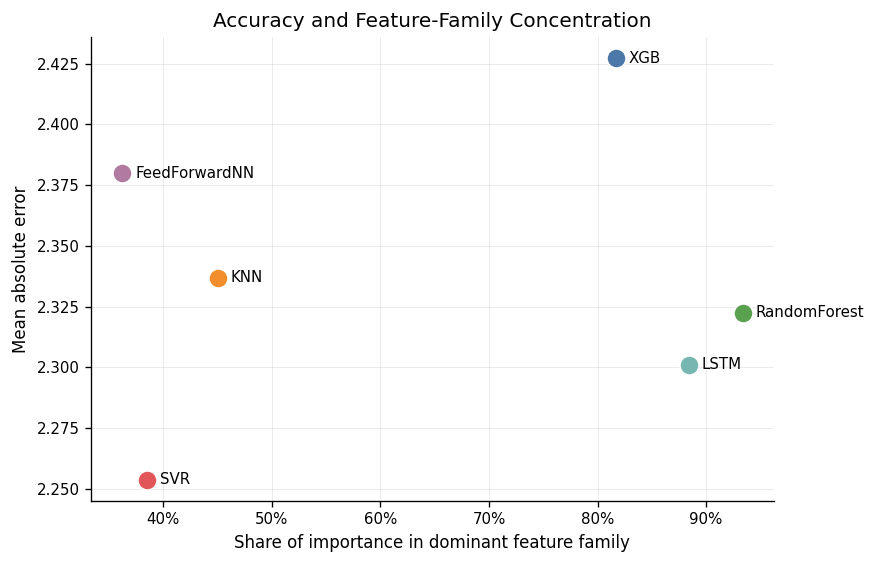

In [49]:
if not performance_profile.empty and not family_importance.empty:
    fam_top = (
        family_importance.sort_values(["model", "importance_share"], ascending=[True, False])
        .groupby("model", as_index=False)
        .first()[["model", "feature_family", "importance_share"]]
    )
    perf_fam = performance_profile.merge(fam_top, on="model", how="inner")
    perf_fam = perf_fam[perf_fam["model"].isin(["XGB", "RandomForest", "SVR", "KNN", "FeedForwardNN", "LSTM"])]

    fig, ax = plt.subplots(figsize=(7.4, 4.8))
    for _, row in perf_fam.iterrows():
        ax.scatter(
            row["importance_share"],
            row["mean_mae"],
            s=130,
            color=MODEL_PALETTE.get(row["model"], "#8C8C8C"),
            edgecolor="white",
            linewidth=0.9,
            zorder=3,
        )
        ax.text(row["importance_share"] + 0.012, row["mean_mae"], row["model"], va="center", fontsize=9)
    ax.set_xlabel("Share of importance in dominant feature family")
    ax.set_ylabel("Mean absolute error")
    ax.set_title("Accuracy and Feature-Family Concentration")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.grid(True)
    fig.tight_layout()
    save_figure(fig, "fig_08_accuracy_vs_feature_family_concentration")
    plt.show()
else:
    print("Need model_performance_profile.csv and feature_family_importance_by_model.csv")